<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/notebooks/extra/extra 05 - Anomaly Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab · Anomaly Detection

Most of the course learned from labelled examples: here is a claim, here is its label, learn the mapping. Anomaly detection starts from the opposite situation. The interesting cases (a fraudulent claim, a failing machine, an intrusion, a corrupted image) are **rare**, **varied** and mostly **unlabelled**. Nobody can list in advance every way a claim can be fraudulent. What we can do is learn what **normal** looks like and score every new case by how far it is from normal.

This lab builds the main families of detectors from scratch, compares them with scikit-learn, and spends as much time on the questions that decide whether a detector is useful in practice: how to evaluate it when anomalies are 1 % of the data, how to choose a threshold, which features to give it, and how to explain an alert to an investigator.

**Contents**

1. What an anomaly is, and why base rates matter
2. One feature: z-score, robust z (median and MAD), IQR fences
3. Several features: Mahalanobis distance, the $\chi^2$ threshold and robust covariance (MCD)
4. Distance and density: $k$-NN distance, kernel density, Gaussian mixture
5. Local Outlier Factor (LOF), by hand and from scratch
6. Isolation Forest, from scratch
7. One-class SVM
8. All methods on three 2-D datasets
9. A real benchmark (Satellite): ROC-AUC, PR-AUC, precision@k, few labels, ensembles
10. Reconstruction error: PCA and an autoencoder on MNIST
11. Synthetic insurance claims: features, Isolation Forest, explanations, costs, labels
12. Time series: seasonality and contextual baselines
13. Summary and exercises

This lab goes with the slides *Extra 5 · Anomaly detection* and uses the same notation. It assumes the classification metrics of the course (precision, recall, ROC, class imbalance), trees and random forests, SVMs with kernels, MLPs in PyTorch, and from earlier extras Gaussian mixtures (Extra 2) and autoencoders (Extra 3). Everything runs on a CPU in about two minutes (40 seconds with 4 CPU threads, plus about 20 seconds of downloads); a GPU is not needed. All insurance data in this lab are **synthetic**: generated in the notebook, no real person behind any row.

**Notation**

| Symbol | Meaning |
|---|---|
| $\mathbf{x} \in \mathbb{R}^d$ | one observation, a row of $\mathbf{X} \in \mathbb{R}^{n \times d}$ |
| $s(\mathbf{x})$ | anomaly score: **higher = more anomalous** (every method is turned into this convention) |
| $\tau$, $k$ | threshold (flag if $s(\mathbf{x}) > \tau$), or alert budget (flag the $k$ highest scores) |
| $\pi$ | base rate: the fraction of anomalies in the data |
| $\mu, \sigma$; $\operatorname{med}$, $\operatorname{MAD}$ | mean and standard deviation; median and median absolute deviation |
| $z = (x - \mu)/\sigma$, $\;z_r = 0.6745\,(x - \operatorname{med})/\operatorname{MAD}$ | z-score and robust z-score |
| $\boldsymbol\mu, \boldsymbol\Sigma$ | mean vector and covariance matrix |
| $D_M(\mathbf{x}) = \sqrt{(\mathbf{x}-\boldsymbol\mu)^\top \boldsymbol\Sigma^{-1} (\mathbf{x}-\boldsymbol\mu)}$ | Mahalanobis distance |
| $\chi^2_d$ | chi-squared distribution with $d$ degrees of freedom |
| $N_k(\mathbf{x})$, $d_k(\mathbf{x})$ | the $k$ nearest neighbours of $\mathbf{x}$, and the distance to the $k$-th one ($k$-distance) |
| $\operatorname{reach}_k(\mathbf{x}, \mathbf{o})$, $\operatorname{lrd}_k$, $\operatorname{LOF}_k$ | reachability distance, local reachability density, local outlier factor |
| $h(\mathbf{x})$, $c(n)$, $\psi$ | path length in an isolation tree, its average for $n$ points, sub-sample size |
| $\nu$, $\gamma$ | one-class SVM: bound on the outlier fraction, RBF kernel width |
| $\hat{\mathbf{x}}$, $\lVert \mathbf{x} - \hat{\mathbf{x}} \rVert^2$ | reconstruction and reconstruction error |
| P@$k$, AP | precision among the $k$ highest scores; average precision (area under the PR curve) |

In [1]:
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
from scipy import stats
import torch
import torch.nn as nn
from sklearn.covariance import EmpiricalCovariance, MinCovDet
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor, KernelDensity
from sklearn.ensemble import IsolationForest, HistGradientBoostingClassifier
from sklearn.svm import OneClassSVM
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.datasets import fetch_openml, make_moons
from torchvision import datasets
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.precision", 3)
np.random.seed(0); torch.manual_seed(0)
# FAST-MCD (scikit-learn) prints this harmless message on some data sets; its result is still the best subset found
warnings.filterwarnings("ignore", message="Determinant has increased", category=RuntimeWarning)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| torch", torch.__version__, "| numpy", np.__version__)
T_START = time.time()

device: cpu | torch 2.12.0+cu130 | numpy 2.3.3


## 1. What an anomaly is, and why base rates matter

An **anomaly** (or outlier) is "an observation which deviates so much from the other observations as to arouse suspicions that it was generated by a different mechanism" (Hawkins, 1980). Three kinds:

- **point anomaly**: one case is unusual on its own. A €40,000 claim on a €15,000 car.
- **contextual anomaly**: unusual only in its context (time, place, type). 300 claims in a day is normal in a January storm and alarming in July. A €3,000 claim is normal for a collision and absurd for a windscreen.
- **collective anomaly**: each case looks normal, the group does not. Twelve ordinary claims, all from young policies, all repaired at the same small garage in one month.

What data do we have? This decides the method more than anything else.

| setting | training data | what it is |
|---|---|---|
| **supervised** | normal and anomalous cases, labelled | imbalanced classification: the course's classifiers with class weights and the metrics of section 9 |
| **semi-supervised** = **novelty detection** | only normal cases (clean) | learn "normal", flag what does not fit (sections 7 and 10) |
| **unsupervised** = **outlier detection** | everything, unlabelled and **contaminated** with an unknown fraction of anomalies | the anomalies must be found inside the training data itself (most of this lab) |

Every method below outputs a **score** $s(\mathbf{x})$, higher meaning more anomalous. A score is not yet a decision: we need a threshold $\tau$, or, more often in practice, an **alert budget** $k$ (an investigation team can review, say, 50 claims a day, so the 50 highest scores are reviewed).

**Base rates.** Fraud is maybe 0.1 % to 1 % of claims. The classifier "everything is normal" has 99.9 % accuracy at a base rate of 0.1 % and catches nothing, so accuracy is useless. Worse, even a good detector produces mostly false alarms. With a true positive rate (recall) TPR, a false positive rate FPR and a base rate $\pi$, Bayes' rule gives the precision of the alerts:

$$
\text{precision} = P(\text{anomaly} \mid \text{alert}) = \frac{\text{TPR}\,\pi}{\text{TPR}\,\pi + \text{FPR}\,(1 - \pi)} .
$$

When $\pi$ is small, the denominator is dominated by $\text{FPR}\,(1-\pi)$, the false alarms among the huge normal majority.

base rate 1.0%: 1000 frauds in 100,000 claims -> 900 caught, 990 false alarms, precision 47.6%, alerts 1,890
base rate 0.1%: 100 frauds in 100,000 claims -> 90 caught, 999 false alarms, precision 8.3%, alerts 1,089
"always normal" at base rate 0.1%: accuracy 99.9%, frauds caught 0


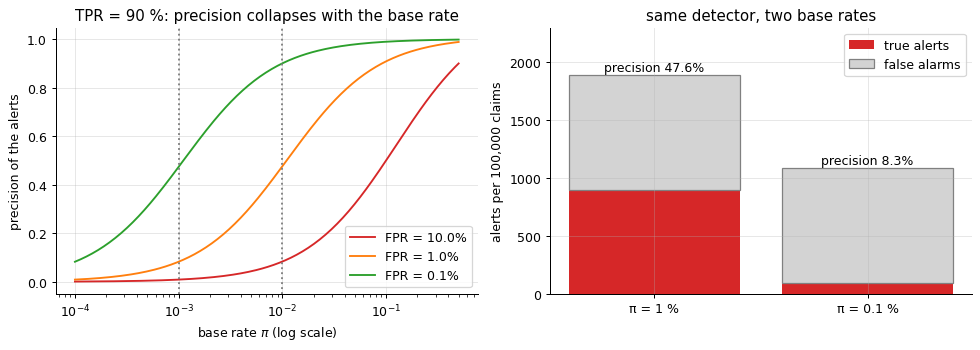

In [2]:
n_claims, tpr, fpr = 100_000, 0.90, 0.01
for pi in (0.01, 0.001):
    n_fraud = round(n_claims * pi); n_ok = n_claims - n_fraud
    tp, fp = tpr * n_fraud, fpr * n_ok
    prec = tp / (tp + fp)
    assert np.isclose(prec, tpr * pi / (tpr * pi + fpr * (1 - pi)))     # counts agree with Bayes' rule
    print(f"base rate {pi:.1%}: {n_fraud} frauds in {n_claims:,} claims -> {tp:.0f} caught, {fp:.0f} false alarms, "
          f"precision {prec:.1%}, alerts {tp + fp:,.0f}")
print(f'"always normal" at base rate 0.1%: accuracy {1 - 0.001:.1%}, frauds caught 0')

pis = np.logspace(-4, -0.3, 200)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for f, c in [(0.1, "tab:red"), (0.01, "tab:orange"), (0.001, "tab:green")]:
    axes[0].plot(pis, tpr * pis / (tpr * pis + f * (1 - pis)), color=c, label=f"FPR = {f:.1%}")
axes[0].set_xscale("log"); axes[0].set_xlabel(r"base rate $\pi$ (log scale)"); axes[0].set_ylabel("precision of the alerts")
axes[0].axvline(0.001, color="gray", ls=":"); axes[0].axvline(0.01, color="gray", ls=":")
axes[0].set_title("TPR = 90 %: precision collapses with the base rate"); axes[0].legend()
for j, pi in enumerate((0.01, 0.001)):
    n_fraud = n_claims * pi; tp, fp = tpr * n_fraud, fpr * (n_claims - n_fraud)
    axes[1].bar(j, tp, color="tab:red", label="true alerts" if j == 0 else None)
    axes[1].bar(j, fp, bottom=tp, color="lightgray", edgecolor="gray", label="false alarms" if j == 0 else None)
    axes[1].text(j, tp + fp + 30, f"precision {tp / (tp + fp):.1%}", ha="center")
axes[1].set_xticks([0, 1], ["π = 1 %", "π = 0.1 %"]); axes[1].set_ylabel("alerts per 100,000 claims")
axes[1].set_title("same detector, two base rates"); axes[1].legend(loc="upper right"); axes[1].set_ylim(0, 2300)
plt.tight_layout(); plt.show()

**What just happened?** The same detector (it catches 90 % of the frauds and wrongly flags 1 % of the honest claims) gives alerts with a precision of 47.6 % at a base rate of 1 %, and only 8.3 % at 0.1 %: out of 1,089 alerts, 90 are frauds and 999 are honest customers. Nothing is wrong with the detector; the honest claims are simply 999 times more numerous.

Three consequences shape the rest of the lab:
- **Never report accuracy.** Report what the investigators will experience: precision among the alerts, recall, and above all **precision@$k$** for the number of alerts they can actually review (section 9).
- **The false positive rate must be tiny.** At $\pi = 0.1\,\%$, getting precision above 50 % with TPR = 90 % needs FPR below 0.09 %.
- **ROC curves hide the problem**, because they plot TPR against FPR and never look at $\pi$. Section 9 shows a detector with ROC-AUC 0.94 and an average precision of 0.15.

## 2. One feature: z-score, robust z, IQR fences

The oldest rule: standardise and flag $|z| > 3$, with $z_i = (x_i - \bar x)/\sigma$. For Gaussian data only 0.27 % of the values exceed 3 in absolute value.

**The problem: the outliers are part of the estimate.** The mean and the standard deviation are computed **with** the outliers, which pull the mean towards them and inflate $\sigma$. A large outlier hides itself and the others: this is **masking**.

**A hard limit.** With $n$ values and the standard deviation $\sigma$ computed with $1/n$ (NumPy's default), no value can have $|z| > \sqrt{n-1}$.

*Proof.* Centre the data so that $\bar x = 0$ and take the most extreme value $x_1$. The other $n-1$ values sum to $-x_1$, so by Cauchy–Schwarz (or "the mean of squares is at least the square of the mean") $\sum_{i\ge2} x_i^2 \ge (n-1)\left(\frac{x_1}{n-1}\right)^2 = \frac{x_1^2}{n-1}$. Then
$n\sigma^2 = \sum_i x_i^2 \ge x_1^2 + \frac{x_1^2}{n-1} = \frac{n\,x_1^2}{n-1}$, so $z_1^2 = x_1^2/\sigma^2 \le n-1$. $\blacksquare$

With $n = 10$ values, $|z| \le 3$ **always**: the "$|z|>3$" rule can never fire, however absurd the value.

**Robust statistics.** Replace the mean by the **median** and $\sigma$ by the **median absolute deviation** $\operatorname{MAD} = \operatorname{med}_i |x_i - \operatorname{med}(x)|$. Both ignore up to half of the data (their **breakdown point** is 50 %, against 0 % for the mean: one value can move the mean anywhere). For a Gaussian, $\operatorname{MAD} = 0.6745\,\sigma$, because $\Phi^{-1}(0.75) = 0.6745$: half of the values lie within $0.6745\,\sigma$ of the median. Hence the **robust z-score**

$$
z_r = 0.6745\,\frac{x - \operatorname{med}(x)}{\operatorname{MAD}},
$$

which behaves like $z$ on clean Gaussian data. A common rule flags $|z_r| > 3.5$ (Iglewicz and Hoaglin).

**Tukey's fences**, the box-plot rule: flag values outside $[Q_1 - 1.5\,\text{IQR},\; Q_3 + 1.5\,\text{IQR}]$, with $\text{IQR} = Q_3 - Q_1$. Also robust; for a Gaussian the fences sit at $\pm 2.70\,\sigma$.

A worked example: ten claim amounts in euros, two of them suspicious.

In [3]:
def zscore(x):
    return (x - x.mean()) / x.std()                  # population std (ddof=0), NumPy's default

def robust_z(x):
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return 0.6745 * (x - med) / mad

def tukey_fences(x, c=1.5):
    q1, q3 = np.percentile(x, [25, 75])
    return q1 - c * (q3 - q1), q3 + c * (q3 - q1)

amounts = np.array([420, 480, 510, 530, 560, 590, 620, 650, 2900, 3100], float)
z, zr = zscore(amounts), robust_z(amounts)
med, mad = np.median(amounts), np.median(np.abs(amounts - np.median(amounts)))
lo, hi = tukey_fences(amounts)
print(f"mean {amounts.mean():.0f}  std {amounts.std():.0f}   |   median {med:.0f}  MAD {mad:.0f}")
print(pd.DataFrame({"amount": amounts, "z": z, "robust z": zr}).T.round(2).to_string(header=False))
print(f"Tukey fences: [{lo:.0f}, {hi:.0f}]  -> flagged: {amounts[(amounts < lo) | (amounts > hi)]}")
print(f"largest |z| = {np.abs(z).max():.2f}  <=  sqrt(n - 1) = {np.sqrt(len(amounts) - 1):.2f}  (the bound)")

# the bound sqrt(n-1) holds for any data; equality for one value apart from n-1 equal ones
rng = np.random.default_rng(0)
worst = max(np.abs(zscore(rng.standard_cauchy(10))).max() for _ in range(20_000))
assert worst <= 3 + 1e-12
assert np.isclose(zscore(np.r_[1.0, np.zeros(9)])[0], 3.0)
print(f"max |z| over 20,000 heavy-tailed samples of size 10: {worst:.4f} (never above 3)")
# robust z = scipy's MAD with the normal scale factor 1/0.6745 = 1.4826
assert np.allclose(zr, (amounts - med) / stats.median_abs_deviation(amounts, scale="normal"), rtol=1e-4)
# Tukey fences for a Gaussian: P(|Z| > 0.6745 + 1.5 * 1.349) = 0.70 %
p_tukey = 2 * stats.norm.sf(stats.norm.ppf(0.75) + 1.5 * (stats.norm.ppf(0.75) - stats.norm.ppf(0.25)))
x_big = rng.normal(size=1_000_000); l_big, h_big = tukey_fences(x_big)
print(f"Gaussian fraction outside Tukey's fences: theory {p_tukey:.4%}, simulation {np.mean((x_big < l_big) | (x_big > h_big)):.4%}")

mean 1036  std 985   |   median 575  MAD 70
amount    420.00  480.00  510.00  530.00  560.00  590.00  620.00  650.00  2900.00  3100.00
z          -0.63   -0.56   -0.53   -0.51   -0.48   -0.45   -0.42   -0.39     1.89     2.10
robust z   -1.49   -0.92   -0.63   -0.43   -0.14    0.14    0.43    0.72    22.40    24.33
Tukey fences: [324, 834]  -> flagged: [2900. 3100.]
largest |z| = 2.10  <=  sqrt(n - 1) = 3.00  (the bound)
max |z| over 20,000 heavy-tailed samples of size 10: 3.0000 (never above 3)


Gaussian fraction outside Tukey's fences: theory 0.6977%, simulation 0.7002%


Now **masking** as the outliers grow. Take 50 values from $\mathcal{N}(0, 1)$ and add $m$ outliers, all equal to $v$. As $v \to \infty$ the mean is about $mv/n$ and the variance about $\frac{m}{n}(1-\frac{m}{n})v^2$ (with $n = 50 + m$), so the z-score of the outliers tends to a **finite** limit:

$$
z \;\to\; \frac{1 - m/n}{\sqrt{\frac{m}{n}\left(1-\frac{m}{n}\right)}} = \sqrt{\frac{n - m}{m}} .
$$

For $m = 5$ that is $\sqrt{50/5} = 3.16$: five outliers of a million euros each barely pass the 3-sigma rule. The robust z grows without limit.

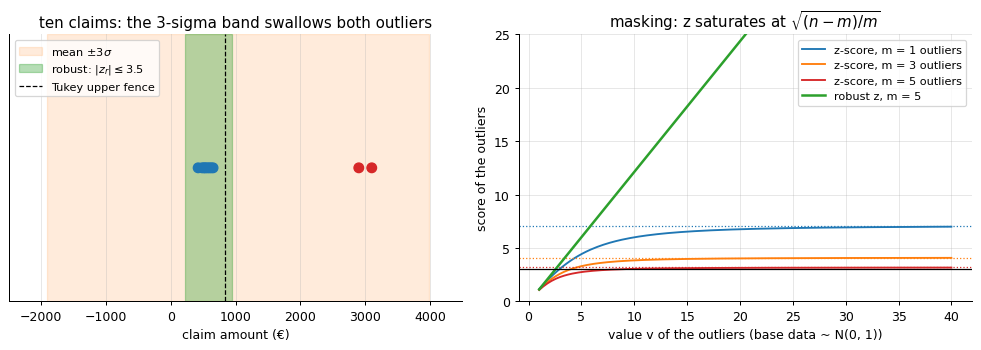

m = 1: z of the outliers when v = 1e9: 7.071   limit sqrt(50/m) = 7.071
m = 3: z of the outliers when v = 1e9: 4.082   limit sqrt(50/m) = 4.082
m = 5: z of the outliers when v = 1e9: 3.162   limit sqrt(50/m) = 3.162


In [4]:
rng = np.random.default_rng(1)
base = rng.normal(size=50)
vs = np.linspace(1, 40, 200)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.scatter(amounts, np.zeros_like(amounts), s=60, c=["tab:red" if a > 2000 else "tab:blue" for a in amounts], zorder=3)
ax.axvspan(amounts.mean() - 3 * amounts.std(), amounts.mean() + 3 * amounts.std(), color="tab:orange", alpha=0.15, label=r"mean $\pm 3\sigma$")
ax.axvspan(med - 3.5 * mad / 0.6745, med + 3.5 * mad / 0.6745, color="tab:green", alpha=0.35, label=r"robust: $|z_r| \leq 3.5$")
ax.axvline(hi, color="k", ls="--", lw=1, label="Tukey upper fence")
ax.set_yticks([]); ax.set_xlabel("claim amount (€)"); ax.set_xlim(-2500, 4500); ax.legend(loc="upper left", fontsize=9)
ax.set_title("ten claims: the 3-sigma band swallows both outliers")
ax = axes[1]
for m, c in [(1, "tab:blue"), (3, "tab:orange"), (5, "tab:red")]:
    zs = [zscore(np.r_[base, np.full(m, v)])[-1] for v in vs]
    ax.plot(vs, zs, color=c, label=f"z-score, m = {m} outliers")
    ax.axhline(np.sqrt(50 / m), color=c, ls=":", lw=1)
ax.plot(vs, [robust_z(np.r_[base, np.full(5, v)])[-1] for v in vs], color="tab:green", lw=2, label="robust z, m = 5")
ax.axhline(3, color="k", lw=1); ax.set_ylim(0, 25); ax.set_xlabel("value v of the outliers (base data ~ N(0, 1))")
ax.set_ylabel("score of the outliers"); ax.legend(fontsize=9); ax.set_title(r"masking: z saturates at $\sqrt{(n-m)/m}$")
plt.tight_layout(); plt.show()

for m in (1, 3, 5):
    z_inf = zscore(np.r_[base, np.full(m, 1e9)])[-1]
    assert np.isclose(z_inf, np.sqrt(50 / m), rtol=1e-6)
    print(f"m = {m}: z of the outliers when v = 1e9: {z_inf:.3f}   limit sqrt(50/m) = {np.sqrt(50 / m):.3f}")

**What just happened?**
- In the ten claims, the mean (€1,036) and the standard deviation (€985) are dragged up by the two large amounts, so their z-scores are only 2.10 and 1.89: by the 3-sigma rule nothing is flagged, and by the bound nothing ever could be with ten values. The median (€575) and the MAD (€70) only look at the eight ordinary amounts: the robust z of €3,100 is 24.3, and Tukey's upper fence (€834) flags both.
- With five equal outliers the z-score saturates at 3.16 however large they are, exactly the limit $\sqrt{(n-m)/m}$; the robust z grows linearly.
- Robust statistics are the cure for masking in one dimension. In several dimensions the same idea gives the robust covariance of section 3.

## 3. Several features: Mahalanobis distance, $\chi^2$ threshold, robust covariance

Features are often **correlated**: a claim amount grows with the vehicle value, a repair time with the damage. A point can be ordinary on each feature separately and still break the relation between them. The Euclidean distance to the mean misses it, because it treats all directions alike. The **Mahalanobis distance** measures the distance in units of the data's own spread in each direction:

$$
D_M(\mathbf{x}) = \sqrt{(\mathbf{x}-\boldsymbol\mu)^\top \boldsymbol\Sigma^{-1} (\mathbf{x}-\boldsymbol\mu)} .
$$

**Why it works: whitening.** Factor $\boldsymbol\Sigma = \mathbf{L}\mathbf{L}^\top$ (Cholesky) and set $\mathbf{z} = \mathbf{L}^{-1}(\mathbf{x} - \boldsymbol\mu)$. Then $\operatorname{Cov}(\mathbf{z}) = \mathbf{L}^{-1}\boldsymbol\Sigma\mathbf{L}^{-\top} = \mathbf{I}$, and

$$
D_M^2(\mathbf{x}) = (\mathbf{x}-\boldsymbol\mu)^\top \mathbf{L}^{-\top}\mathbf{L}^{-1}(\mathbf{x}-\boldsymbol\mu) = \lVert \mathbf{z} \rVert^2 :
$$

the Mahalanobis distance is the Euclidean distance after decorrelating and rescaling the features. The contours $D_M = c$ are ellipses aligned with the data.

**The threshold.** If $\mathbf{x} \sim \mathcal{N}(\boldsymbol\mu, \boldsymbol\Sigma)$, then $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ and $D_M^2 = z_1^2 + \dots + z_d^2$ is a sum of $d$ squared independent standard normals: $D_M^2 \sim \chi^2_d$. So "flag the 2.5 % most extreme Gaussian points" means $D_M^2 > \chi^2_{d,\,0.975}$, which is 7.38 for $d = 2$ (an ellipse at $D_M = 2.72$).

point A: Euclidean 3.11   Mahalanobis 2.27 (with the true Sigma: 2.32)
point B: Euclidean 1.68   Mahalanobis 3.74 (with the true Sigma: 3.79)
chi2(2) 97.5% quantile = 7.378  -> D threshold 2.716;  fraction of the 500 Gaussian points above it: 3.0% (expected 2.5%)


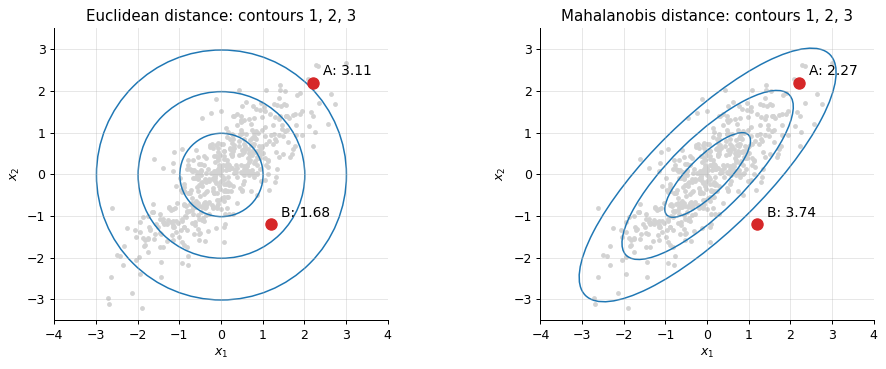

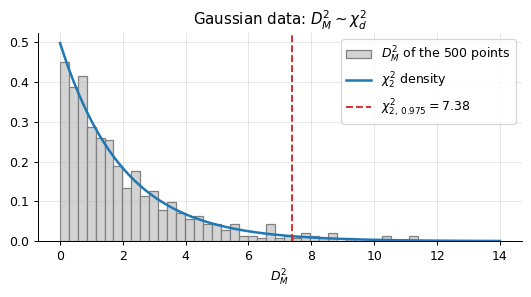

In [5]:
def mahalanobis(X, mu, S):
    # whitening: Z = L^{-1} (X - mu)^T with S = L L^T, then D = ||z||
    L = np.linalg.cholesky(S)
    Z = np.linalg.solve(L, (X - mu).T).T
    return np.sqrt((Z ** 2).sum(1))

rng = np.random.default_rng(2)
S_true = np.array([[1.0, 0.8], [0.8, 1.0]])
X_cor = rng.multivariate_normal([0, 0], S_true, size=500)
mu_hat, S_hat = X_cor.mean(0), np.cov(X_cor.T, bias=True)
P_AB = np.array([[2.2, 2.2], [1.2, -1.2]])                 # A: along the correlation, B: against it
d_eu = np.linalg.norm(P_AB - mu_hat, axis=1); d_ma = mahalanobis(P_AB, mu_hat, S_hat)
d_ma_true = mahalanobis(P_AB, np.zeros(2), S_true)
for name, de, dm, dt in zip("AB", d_eu, d_ma, d_ma_true):
    print(f"point {name}: Euclidean {de:.2f}   Mahalanobis {dm:.2f} (with the true Sigma: {dt:.2f})")

D_all = mahalanobis(X_cor, mu_hat, S_hat)
assert np.allclose(D_all ** 2, EmpiricalCovariance().fit(X_cor).mahalanobis(X_cor))   # sklearn returns D^2
thr = stats.chi2.ppf(0.975, df=2)
print(f"chi2(2) 97.5% quantile = {thr:.3f}  -> D threshold {np.sqrt(thr):.3f};  "
      f"fraction of the 500 Gaussian points above it: {np.mean(D_all ** 2 > thr):.1%} (expected 2.5%)")

def ellipse(ax, mu, S, r, **kw):
    # the contour (x - mu)^T S^{-1} (x - mu) = r^2
    vals, vecs = np.linalg.eigh(S)
    ang = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))
    ax.add_patch(Ellipse(mu, 2 * r * np.sqrt(vals[1]), 2 * r * np.sqrt(vals[0]), angle=ang, fill=False, **kw))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, kind in zip(axes, ["Euclidean", "Mahalanobis"]):
    ax.scatter(*X_cor.T, s=8, c="lightgray")
    for r in (1, 2, 3):
        if kind == "Euclidean":
            ax.add_patch(Circle(mu_hat, r, fill=False, color="tab:blue", lw=1.2))
        else:
            ellipse(ax, mu_hat, S_hat, r, color="tab:blue", lw=1.2)
    for (px, py), name, de, dm in zip(P_AB, "AB", d_eu, d_ma):
        ax.scatter(px, py, s=80, c="tab:red", zorder=3)
        ax.annotate(f"{name}: {de if kind == 'Euclidean' else dm:.2f}", (px, py), xytext=(8, 6), textcoords="offset points", fontsize=11)
    ax.set_aspect("equal"); ax.set_xlim(-4, 4); ax.set_ylim(-3.5, 3.5)
    ax.set_title(f"{kind} distance: contours 1, 2, 3"); ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.hist(D_all ** 2, bins=40, density=True, color="lightgray", edgecolor="gray", label=r"$D_M^2$ of the 500 points")
t = np.linspace(0.01, 14, 300); ax.plot(t, stats.chi2.pdf(t, 2), "tab:blue", lw=2, label=r"$\chi^2_2$ density")
ax.axvline(thr, color="tab:red", ls="--", label=r"$\chi^2_{2,\,0.975} = 7.38$"); ax.set_xlabel(r"$D_M^2$"); ax.legend()
ax.set_title(r"Gaussian data: $D_M^2 \sim \chi^2_d$"); plt.tight_layout(); plt.show()

**What just happened?** Point A is far from the centre in Euclidean terms (3.11) but lies along the direction where the data are spread out, so its Mahalanobis distance is only 2.27. Point B is closer in Euclidean terms (1.68) but goes **against** the correlation: Mahalanobis distance 3.74, beyond the 2.72 threshold. The squared distances of the 500 Gaussian points follow the $\chi^2_2$ density, and 3.0 % (15 points) of them exceed the 97.5 % quantile, as predicted.

**The catch: masking again.** $\boldsymbol\mu$ and $\boldsymbol\Sigma$ are estimated from data that contain the outliers. A group of outliers drags the mean towards itself and stretches the covariance in its direction, until its own Mahalanobis distances look ordinary.

**The fix: the Minimum Covariance Determinant (MCD)** (Rousseeuw, 1984). Among all subsets of $h \approx n/2$ points, find the one whose covariance matrix has the **smallest determinant** (the tightest ellipse), and estimate $\boldsymbol\mu, \boldsymbol\Sigma$ from it. Up to $n - h$ outliers cannot influence the estimate. The search is combinatorial, but the **C-step** makes it practical (Rousseeuw and Van Driessen, 1999): given a subset $H$, compute its mean and covariance, then keep the $h$ points with the smallest Mahalanobis distances. **Theorem**: the determinant never increases. So repeat C-steps from many random starts and keep the best. The raw estimate uses only the central half of the data, so its covariance is too small; it is multiplied by the consistency factor $\operatorname{med}(D^2)/\chi^2_{d,\,0.5}$ (scikit-learn then re-weights, refitting on the points below the 97.5 % quantile).

In [6]:
def mcd_csteps(X, h, n_starts=30, max_steps=50, seed=0):
    # FAST-MCD in its simplest form: C-steps from random h-subsets, keep the smallest determinant
    rng = np.random.default_rng(seed)
    best_det, best_H, trace = np.inf, None, None
    for s in range(n_starts):
        H = np.sort(rng.choice(len(X), h, replace=False)); dets = []
        for _ in range(max_steps):
            mu, S = X[H].mean(0), np.cov(X[H].T, bias=True)
            dets.append(np.linalg.det(S))
            H_new = np.sort(np.argsort(mahalanobis(X, mu, S))[:h])   # the h points closest to the current fit
            if np.array_equal(H_new, H):
                break
            H = H_new
        assert all(a >= b - 1e-12 for a, b in zip(dets, dets[1:]))   # C-step theorem: det never increases
        if dets[-1] < best_det:
            best_det, best_H, trace = dets[-1], H, dets
    return X[best_H].mean(0), np.cov(X[best_H].T, bias=True), best_H, trace

rng = np.random.default_rng(3)
X_in = rng.multivariate_normal([0, 0], [[1.0, 0.6], [0.6, 1.0]], size=300)
X_out = rng.normal([3.0, -2.2], 0.35, size=(45, 2))            # a tight group: 13 % of the data
X_mix = np.vstack([X_in, X_out]); y_mix = np.r_[np.zeros(300), np.ones(45)].astype(bool)
d = 2; h = (len(X_mix) + d + 1) // 2

mu_c, S_c = X_mix.mean(0), np.cov(X_mix.T, bias=True)          # classical: uses the outliers too
mu_r, S_raw, H, trace = mcd_csteps(X_mix, h)
D2_raw = mahalanobis(X_mix, mu_r, S_raw) ** 2
S_r = S_raw * np.median(D2_raw) / stats.chi2.ppf(0.5, d)        # consistency correction
D2_c, D2_r = mahalanobis(X_mix, mu_c, S_c) ** 2, mahalanobis(X_mix, mu_r, S_r) ** 2

mcd = MinCovDet(support_fraction=h / len(X_mix), random_state=0).fit(X_mix)
print(f"h = {h} of {len(X_mix)} points; C-steps of the best start: det {' -> '.join(f'{v:.4f}' for v in trace)}")
print(f"our raw support == sklearn raw support: {np.array_equal(np.sort(H), np.flatnonzero(mcd.raw_support_))}")
print(f"location  classical {mu_c.round(3)}   ours {mu_r.round(3)}   sklearn raw {mcd.raw_location_.round(3)}   true [0 0]")
print(f"correlation  classical {S_c[0, 1] / np.sqrt(S_c[0, 0] * S_c[1, 1]):.2f}   robust {S_r[0, 1] / np.sqrt(S_r[0, 0] * S_r[1, 1]):.2f}   true 0.60")
for name, D2 in [("classical", D2_c), ("MCD (ours)", D2_r), ("MCD (sklearn)", mcd.mahalanobis(X_mix))]:
    flag = D2 > thr
    print(f"{name:14s}: planted outliers flagged {np.sum(flag & y_mix):2d} / 45,  normal points flagged {np.sum(flag & ~y_mix):2d} / 300")
assert np.allclose(mu_r, mcd.raw_location_)

h = 174 of 345 points; C-steps of the best start: det 3.4333 -> 0.1060 -> 0.0844 -> 0.0803 -> 0.0793 -> 0.0790 -> 0.0786 -> 0.0784
our raw support == sklearn raw support: True
location  classical [ 0.343 -0.238]   ours [-0.12   0.084]   sklearn raw [-0.12   0.084]   true [0 0]
correlation  classical -0.14   robust 0.48   true 0.60
classical     : planted outliers flagged  2 / 45,  normal points flagged  3 / 300
MCD (ours)    : planted outliers flagged 45 / 45,  normal points flagged  5 / 300
MCD (sklearn) : planted outliers flagged 45 / 45,  normal points flagged  8 / 300


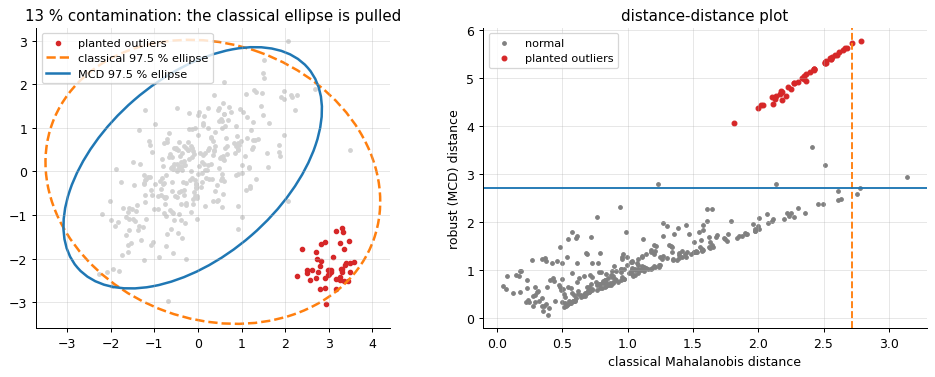

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
ax = axes[0]
ax.scatter(*X_mix[~y_mix].T, s=8, c="lightgray"); ax.scatter(*X_mix[y_mix].T, s=12, c="tab:red", label="planted outliers")
ellipse(ax, mu_c, S_c, np.sqrt(thr), color="tab:orange", lw=2, ls="--"); ellipse(ax, mu_r, S_r, np.sqrt(thr), color="tab:blue", lw=2)
ax.plot([], [], color="tab:orange", ls="--", lw=2, label="classical 97.5 % ellipse"); ax.plot([], [], color="tab:blue", lw=2, label="MCD 97.5 % ellipse")
ax.set_aspect("equal"); ax.legend(loc="upper left", fontsize=9); ax.set_title("13 % contamination: the classical ellipse is pulled")
ax = axes[1]
ax.scatter(np.sqrt(D2_c[~y_mix]), np.sqrt(D2_r[~y_mix]), s=8, c="gray", label="normal")
ax.scatter(np.sqrt(D2_c[y_mix]), np.sqrt(D2_r[y_mix]), s=14, c="tab:red", label="planted outliers")
ax.axvline(np.sqrt(thr), color="tab:orange", ls="--"); ax.axhline(np.sqrt(thr), color="tab:blue")
ax.set_xlabel("classical Mahalanobis distance"); ax.set_ylabel("robust (MCD) distance"); ax.legend(fontsize=9)
ax.set_title("distance-distance plot"); plt.tight_layout(); plt.show()

**Interpretation.**
- The classical estimate is fooled: the 45 outliers move its mean to (0.34, −0.24) and turn the positive correlation of the normal data (0.60) into −0.14. Inside the resulting fat ellipse, only 2 of the 45 planted outliers exceed the 97.5 % threshold.
- The C-steps reduced the determinant at every step (from 3.43 to 0.078 in seven C-steps) and found exactly the same subset as scikit-learn's FAST-MCD. The robust fit (location (−0.12, 0.08), correlation 0.48) ignores the group: 45 of 45 flagged, with 5 false alarms among the 300 normal points (2.5 % expected by construction: 7.5).
- The **distance-distance plot** (Rousseeuw and van Zomeren) shows the masking at a glance: the red points have small classical distances but huge robust ones.
- Limits: MCD needs $n > d$ comfortably and becomes slow and unstable in high dimension (it assumes one elliptical cloud). The next methods drop the Gaussian assumption altogether.

## 4. Distance and density: $k$-NN distance, kernel density, Gaussian mixture

Drop the single-ellipse assumption. Two natural ideas:

- **Distance**: an anomaly is far from the other points. Score $s(\mathbf{x}) = d_k(\mathbf{x})$, the distance to its $k$-th nearest neighbour (Ramaswamy et al., 2000). Simple, no training, works with any shape; $O(n^2)$ naively, much less with a tree index.
- **Density**: an anomaly lies where the data are rare. Estimate a density $\hat p$ and use $s(\mathbf{x}) = -\log \hat p(\mathbf{x})$. With a **kernel density estimate** $\hat p(\mathbf{x}) = \frac1n \sum_i K_h(\mathbf{x} - \mathbf{x}_i)$ (a bump of width $h$ on every point), or with a **Gaussian mixture** $\hat p(\mathbf{x}) = \sum_j w_j\,\mathcal{N}(\mathbf{x}; \boldsymbol\mu_j, \boldsymbol\Sigma_j)$ fitted by EM, as in Extra 2. The $k$-NN distance is itself a density estimate in disguise: the ball of radius $d_k(\mathbf{x})$ contains $k$ points, so $\hat p(\mathbf{x}) \approx k / (n\,V_d\,d_k(\mathbf{x})^d)$.

The $k$-NN distance and the KDE are **global** scores: one scale ($k$, or the bandwidth $h$) and one threshold for the whole space. A GMM gives every component its own covariance, so its scale adapts to each cluster, but only if the data really are a mixture of a few Gaussians. The test data set below shows the difference. It has a **dense** cluster (150 points, $\sigma = 0.3$), a **sparse** cluster (150 points, $\sigma = 1.2$), two **local outliers** just outside the dense cluster, and eight **global outliers** far from everything: 10 anomalies in 310 points.

In [8]:
def make_two_densities(seed=1):
    rng = np.random.default_rng(seed)
    dense = rng.normal([0.0, 0.0], 0.3, size=(150, 2))
    sparse = rng.normal([5.0, 4.0], 1.2, size=(150, 2))
    local = np.array([[1.25, -0.35], [-0.35, 1.25]])                       # 4 sigma from the dense centre
    glob = np.array([[-3.0, 4.0], [-2.5, -3.0], [2.5, -3.5], [9.5, 0.5], [10.0, 7.5], [2.5, 8.5], [-3.5, 0.5], [8.5, -2.0]])
    X = np.vstack([dense, sparse, local, glob])
    group = np.r_[np.zeros(150), np.ones(150), np.full(2, 2), np.full(8, 3)].astype(int)   # 0 dense, 1 sparse, 2 local, 3 global
    return X, group

X2, g2 = make_two_densities()
y2 = (g2 >= 2).astype(int)
GROUP = ["dense cluster", "sparse cluster", "local outlier", "global outlier"]
GCOL = np.array(["tab:blue", "tab:green", "tab:red", "black"])

def knn_distance(X_train, X_query, k, exclude_self=False):
    D = np.sqrt(((X_query[:, None, :] - X_train[None, :, :]) ** 2).sum(-1))
    if exclude_self:
        np.fill_diagonal(D, np.inf)                      # a training point is not its own neighbour
    return np.sort(D, axis=1)[:, k - 1]

k = 10
s_knn = knn_distance(X2, X2, k, exclude_self=True)
dist, _ = NearestNeighbors(n_neighbors=k + 1).fit(X2).kneighbors(X2)   # column 0 is the point itself
assert np.allclose(s_knn, dist[:, k])
s_kde = -KernelDensity(bandwidth=0.4).fit(X2).score_samples(X2)
gmm2 = GaussianMixture(2, random_state=0).fit(X2)
s_gmm = -gmm2.score_samples(X2)

def rank_of(s, idx):
    # rank 1 = the highest score
    order = np.argsort(-s)
    return [int(np.flatnonzero(order == i)[0]) + 1 for i in idx]

loc_idx = np.flatnonzero(g2 == 2)
for name, s in [("kNN distance (k=10)", s_knn), ("KDE  -log p", s_kde), ("GMM  -log p", s_gmm)]:
    r = rank_of(s, loc_idx)
    n_sparse_above = np.sum((g2 == 1) & (s > s[loc_idx].min()))
    print(f"{name:20s} AUC {roc_auc_score(y2, s):.3f} | ranks of the 2 local outliers: {r} | sparse-cluster points scored above them: {n_sparse_above}")
print("GMM means:", gmm2.means_.round(2).tolist(), " weights:", gmm2.weights_.round(2))

kNN distance (k=10)  AUC 0.986 | ranks of the 2 local outliers: [31, 29] | sparse-cluster points scored above them: 21
KDE  -log p          AUC 0.985 | ranks of the 2 local outliers: [31, 32] | sparse-cluster points scored above them: 22
GMM  -log p          AUC 1.000 | ranks of the 2 local outliers: [10, 9] | sparse-cluster points scored above them: 0
GMM means: [[4.8, 3.89], [-0.04, -0.02]]  weights: [0.52 0.48]


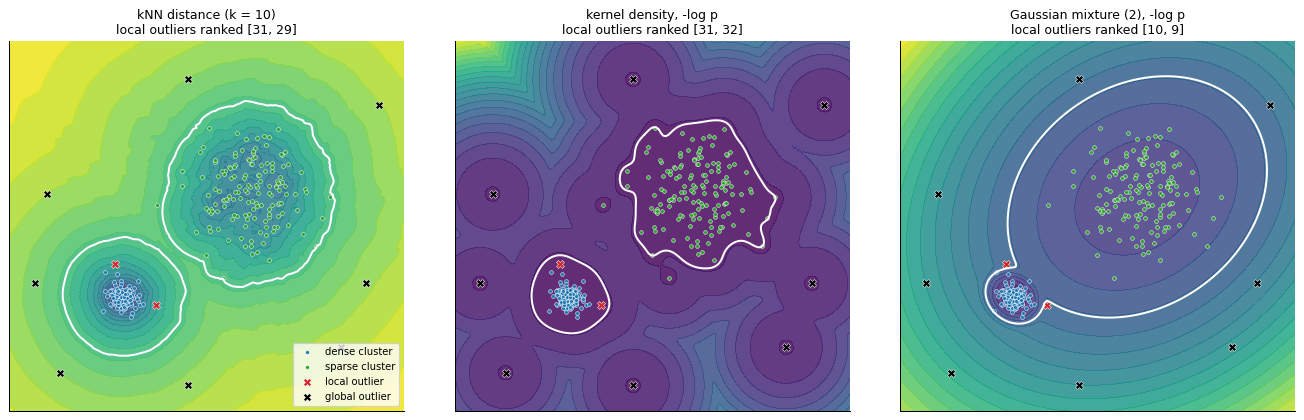

In [9]:
gx, gy = np.meshgrid(np.linspace(-4.5, 11, 160), np.linspace(-4.5, 10, 150))
G2 = np.c_[gx.ravel(), gy.ravel()]

def score_map(ax, S, X, group, title, q=None, cmap="viridis"):
    # S: scores on the grid (higher = more anomalous); q: contour level (e.g. a quantile of the training scores)
    ax.contourf(gx, gy, S.reshape(gx.shape), levels=20, cmap=cmap, alpha=0.85)
    if q is not None:
        ax.contour(gx, gy, S.reshape(gx.shape), levels=[q], colors="white", linewidths=1.6)
    for gi in range(4):
        m = group == gi
        ax.scatter(*X[m].T, s=9 if gi < 2 else 40, c=GCOL[gi], edgecolors="white", linewidths=0.4, marker="o" if gi < 2 else "X", label=GROUP[gi])
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")

maps = {"kNN distance (k = 10)": (np.log(knn_distance(X2, G2, k)), np.log(s_knn)),
        "kernel density, -log p": (-KernelDensity(bandwidth=0.4).fit(X2).score_samples(G2), s_kde),
        "Gaussian mixture (2), -log p": (-gmm2.score_samples(G2), s_gmm)}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (name, (S, s_tr)) in zip(axes, maps.items()):
    q = np.quantile(s_tr, 1 - 10 / 310)                 # the contour that flags 10 training points
    score_map(ax, S, X2, g2, f"{name}\nlocal outliers ranked {rank_of(s_tr, loc_idx)}", q)
axes[0].legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

**Things to notice.**
- The $k$-NN distance and the KDE find the eight global outliers but rank the two **local outliers** only 31st and 29th (KDE: 31st and 32nd). 21 points of the sparse cluster have a larger $k$-NN distance than the less extreme local outlier. The white contour (the threshold that flags 10 training points) wraps the dense cluster tightly but leaves the local outliers inside, while it cuts into the edge of the sparse cluster.
- The reason: both scores measure an **absolute** density with one smoothing scale. A point 1.3 away from the dense cluster lives in a region about as sparse as the edge of the sparse cluster, where points are perfectly normal for *their* cluster.
- The GMM is perfect here (AUC 1.000, local outliers ranked 10th and 9th, right after the 8 global ones): with two Gaussian components, the dense one has $\sigma = 0.3$, and 4 of its standard deviations away the likelihood is tiny. A correct parametric model wins. But the data must really be a few Gaussians, and the number of components must be right (Extra 2); real clusters rarely are.

A model-free way to get the same effect: compare each point's density with the density of **its own neighbours**, a **local** score.

## 5. Local Outlier Factor (LOF)

LOF (Breunig et al., 2000) divides the density around each point by the density around its neighbours. Four definitions, each built on the previous one, for a fixed $k$:

1. **$k$-distance** $d_k(\mathbf{o})$: the distance from $\mathbf{o}$ to its $k$-th nearest neighbour. $N_k(\mathbf{o})$ is the set of those $k$ neighbours.
2. **Reachability distance** of $\mathbf{x}$ from a neighbour $\mathbf{o}$:
$$\operatorname{reach}_k(\mathbf{x}, \mathbf{o}) = \max\{\,d(\mathbf{x}, \mathbf{o}),\ d_k(\mathbf{o})\,\}.$$
The true distance, except that points **inside** $\mathbf{o}$'s neighbourhood are all treated as being at distance $d_k(\mathbf{o})$. This smooths the statistics: tiny distances between near-duplicates do not create huge densities. (It is not symmetric.)
3. **Local reachability density**, the inverse of the mean reachability distance to the neighbours:
$$\operatorname{lrd}_k(\mathbf{x}) = \Big(\frac{1}{k}\sum_{\mathbf{o} \in N_k(\mathbf{x})} \operatorname{reach}_k(\mathbf{x}, \mathbf{o})\Big)^{-1}.$$
4. **Local outlier factor**, the mean density of the neighbours relative to the point's own:
$$\operatorname{LOF}_k(\mathbf{x}) = \frac{1}{k}\sum_{\mathbf{o} \in N_k(\mathbf{x})} \frac{\operatorname{lrd}_k(\mathbf{o})}{\operatorname{lrd}_k(\mathbf{x})}.$$

$\operatorname{LOF} \approx 1$: as dense as its neighbours (inside a cluster, whatever the cluster's density). $\operatorname{LOF} \gg 1$: much sparser than its neighbours, an outlier. $\operatorname{LOF} < 1$: denser than its neighbours.

**By hand.** Six points and $k = 2$: a cluster A, B, C, D (a 1 × 2 rectangle), a point E near it and a point F far away. The same example is worked step by step in the slides.

In [10]:
P6 = np.array([[0, 0], [0, 2], [1, 0], [1, 2], [3, 3], [8, 6]], float)
NAMES6 = list("ABCDEF")

def lof_scratch(X, k):
    D = np.sqrt(((X[:, None, :] - X[None, :, :]) ** 2).sum(-1))
    np.fill_diagonal(D, np.inf)
    nbrs = np.argsort(D, axis=1, kind="stable")[:, :k]                    # N_k(x)
    kdist = D[np.arange(len(X)), nbrs[:, -1]]                              # d_k(x)
    reach = np.maximum(D[np.arange(len(X))[:, None], nbrs], kdist[nbrs])   # reach_k(x, o) = max(d(x, o), d_k(o))
    lrd = 1 / reach.mean(axis=1)
    lof = lrd[nbrs].mean(axis=1) / lrd
    return kdist, nbrs, reach, lrd, lof

kd6, nb6, reach6, lrd6, lof6 = lof_scratch(P6, k=2)
table6 = pd.DataFrame({"N_2": ["".join(NAMES6[j] for j in r) for r in nb6], "d_2": kd6,
                       "reach to 1st": reach6[:, 0], "reach to 2nd": reach6[:, 1], "lrd": lrd6, "LOF": lof6}, index=NAMES6)
print(table6.round(3).to_string())
sk_lof6 = LocalOutlierFactor(n_neighbors=2).fit(P6)
assert np.allclose(-sk_lof6.negative_outlier_factor_, lof6)          # sklearn stores -LOF
print("\nscikit-learn LOF:", (-sk_lof6.negative_outlier_factor_).round(3), " (identical)")
print(f"E: reach = max(d(E,D) = {np.hypot(2, 1):.3f}, d_2(D) = {kd6[3]:.0f}) and max(d(E,B) = {np.hypot(3, 1):.3f}, d_2(B) = {kd6[1]:.0f})"
      f" -> lrd(E) = 1 / {reach6[4].mean():.3f} = {lrd6[4]:.4f};  LOF(E) = mean({lrd6[3]:.2f}, {lrd6[1]:.2f}) / {lrd6[4]:.4f} = {lof6[4]:.3f}")

  N_2    d_2  reach to 1st  reach to 2nd    lrd    LOF
A  CB  2.000         2.000         2.000  0.500  1.000
B  DA  2.000         2.000         2.000  0.500  1.000
C  AD  2.000         2.000         2.000  0.500  1.000
D  BC  2.000         2.000         2.000  0.500  1.000
E  DB  3.162         2.236         3.162  0.370  1.350
F  ED  8.062         5.831         8.062  0.144  3.023

scikit-learn LOF: [1.    1.    1.    1.    1.35  3.023]  (identical)
E: reach = max(d(E,D) = 2.236, d_2(D) = 2) and max(d(E,B) = 3.162, d_2(B) = 2) -> lrd(E) = 1 / 2.699 = 0.3705;  LOF(E) = mean(0.50, 0.50) / 0.3705 = 1.350


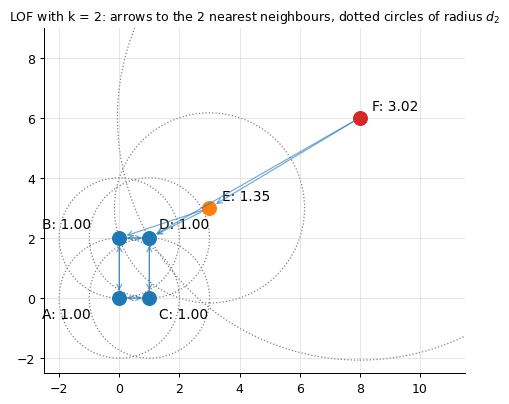

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for i, (p, name) in enumerate(zip(P6, NAMES6)):
    ax.add_patch(Circle(p, kd6[i], fill=False, ls=":", color="gray", lw=1))
    for j in nb6[i]:
        ax.annotate("", xy=P6[j], xytext=p, arrowprops=dict(arrowstyle="->", color="tab:blue", lw=1, alpha=0.6, shrinkA=6, shrinkB=6))
    ax.scatter(*p, s=120, c="tab:red" if lof6[i] > 1.5 else ("tab:orange" if lof6[i] > 1.1 else "tab:blue"), zorder=3)
    off = {"A": (-62, -16), "B": (-62, 8), "C": (8, -16), "D": (8, 8), "E": (10, 6), "F": (10, 6)}[name]
    ax.annotate(f"{name}: {lof6[i]:.2f}", p, xytext=off, textcoords="offset points", fontsize=11)
ax.set_aspect("equal"); ax.set_xlim(-2.5, 11.5); ax.set_ylim(-2.5, 9)
ax.set_title("LOF with k = 2: arrows to the 2 nearest neighbours, dotted circles of radius $d_2$", fontsize=10); plt.tight_layout(); plt.show()

**Reading the table.** Every corner of the rectangle has its two neighbours at distances 1 and 2, so $d_2 = 2$. Their reachability distances are $\max(1, 2) = 2$ and $\max(2, 2) = 2$: the $\max$ replaces the short distance 1 by the neighbour's $k$-distance, which is the smoothing at work. So every corner has $\operatorname{lrd} = 1/2$ and $\operatorname{LOF} = 1$ exactly: a point inside a uniform cluster scores 1, whatever the cluster's density.

E's neighbours are D (at $\sqrt5 = 2.236$) and B (at $\sqrt{10} = 3.162$); both are farther than the corners' $k$-distance 2, so the reachability distances are the true ones, $\operatorname{lrd}(E) = 1/2.699 = 0.370$, and $\operatorname{LOF}(E) = 0.5/0.370 = 1.35$: a bit sparser than its neighbours. F's neighbours are E (at $\sqrt{34} = 5.831$) and D (at $\sqrt{65} = 8.062$): $\operatorname{lrd}(F) = 0.144$, and the neighbours are about three times denser: $\operatorname{LOF}(F) = 3.02$. scikit-learn's `LocalOutlierFactor` gives exactly the same numbers (it stores $-\operatorname{LOF}$ in `negative_outlier_factor_`).

Now LOF on the two-density data, from scratch and with scikit-learn, and the role of $k$.

LOF (k = 20) from scratch == sklearn: True
kNN distance  AUC 0.986   ranks of the local outliers [31, 29]   top 10 contains 8 of the 10 anomalies
LOF           AUC 1.000   ranks of the local outliers [9, 7]   top 10 contains 10 of the 10 anomalies
LOF of the two local outliers: [3.35 3.97]   median LOF in the dense / sparse cluster: 1.06 1.01


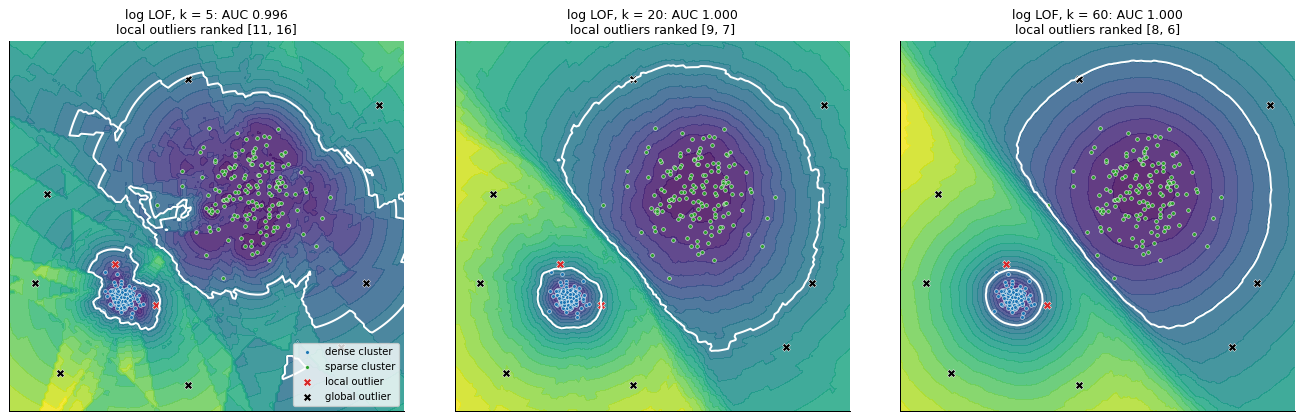

In [12]:
k_lof = 20
_, _, _, _, s_lof = lof_scratch(X2, k_lof)
sk_lof = LocalOutlierFactor(n_neighbors=k_lof).fit(X2)
assert np.allclose(s_lof, -sk_lof.negative_outlier_factor_)
print(f"LOF (k = {k_lof}) from scratch == sklearn: True")
for name, s in [("kNN distance", s_knn), ("LOF", s_lof)]:
    print(f"{name:13s} AUC {roc_auc_score(y2, s):.3f}   ranks of the local outliers {rank_of(s, loc_idx)}   "
          f"top 10 contains {np.sum(y2[np.argsort(-s)[:10]])} of the 10 anomalies")
print("LOF of the two local outliers:", s_lof[loc_idx].round(2), "  median LOF in the dense / sparse cluster:",
      np.median(s_lof[g2 == 0]).round(2), np.median(s_lof[g2 == 1]).round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, kk in zip(axes, (5, 20, 60)):
    m = LocalOutlierFactor(n_neighbors=kk, novelty=True).fit(X2)            # novelty=True: score new points (the grid)
    s_tr = -LocalOutlierFactor(n_neighbors=kk).fit(X2).negative_outlier_factor_
    S = np.log(-m.score_samples(G2))
    score_map(ax, S, X2, g2, f"log LOF, k = {kk}: AUC {roc_auc_score(y2, s_tr):.3f}\nlocal outliers ranked {rank_of(s_tr, loc_idx)}",
              np.log(np.quantile(s_tr, 1 - 10 / 310)))
axes[0].legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

**What just happened?** With $k = 20$, LOF ranks the two local outliers 9th and 7th (the $k$-NN distance: 31st and 29th) and its top 10 contains all 10 anomalies (the $k$-NN distance: 8). Inside both clusters the median LOF is close to 1 (1.06 in the dense one, 1.01 in the sparse one): the score has removed the difference in density, which is exactly what a global score cannot do.

**The choice of $k$.** With $k = 5$ the score is noisy: small random gaps inside the sparse cluster look like local outliers, and the map is full of holes. With a large $k$ the neighbourhood of a local outlier includes far points and LOF becomes more global. A second effect: a **group** of $m$ outliers close together are each other's neighbours when $k \le m$, so they look normal (a micro-cluster masks itself). Rule of thumb from the LOF paper: $k$ at least 10 to 20, and larger than the biggest group of anomalies you want to catch. In practice take the maximum (or mean) LOF over a range of $k$.

**Costs.** LOF needs the $k$ nearest neighbours of every point: $O(n^2 d)$ naively, $O(n \log n)$ with a tree in low dimension. And like every distance-based method it depends on the **scaling** of the features: standardise first (section 9).

## 6. Isolation Forest

A completely different idea (Liu, Ting and Zhou, 2008). Do not model the normal data at all. **Isolate** points instead: pick a random feature, a random split value between its min and max, and recurse until every point is alone. Anomalies are few and different, so random cuts separate them from the rest **early**; a point deep inside a cluster needs many cuts.

An **isolation tree** is built on a random sub-sample of $\psi$ points (default 256), up to a height limit $\lceil \log_2 \psi \rceil = 8$. The **path length** $h(\mathbf{x})$ is the number of edges from the root to the leaf where $\mathbf{x}$ ends. If that leaf still holds $m > 1$ training points (the height limit stopped the growth), we add $c(m)$, the expected depth still needed to separate them.

**The normaliser.** For $n$ points, the average path length of an unsuccessful search in a binary search tree is

$$
c(n) = 2H(n-1) - \frac{2(n-1)}{n}, \qquad H(i) \approx \ln i + 0.5772 \ (\text{Euler's constant}),
$$

with $c(2) = 1$ and $c(1) = 0$. It is the typical depth of a point in a random tree on $n$ points, so it puts path lengths on a common scale. The **anomaly score** averages $h$ over $T$ trees:

$$
s(\mathbf{x}, \psi) = 2^{-\mathbb{E}[h(\mathbf{x})]/c(\psi)} .
$$

$\mathbb{E}[h] \to 0$ gives $s \to 1$ (isolated at once); $\mathbb{E}[h] = c(\psi)$ gives $s = 0.5$ (a typical point); $\mathbb{E}[h] \to \psi - 1$ gives $s \to 0$. scikit-learn's `score_samples` returns $-s$.

**Why sub-sample?** Small samples make isolation easier, not harder: fewer normal points around an anomaly (less **swamping**, normal points near anomalies looking anomalous) and less **masking** by groups of anomalies. And the cost is $O(T\,\psi \log \psi)$ to build, $O(T \log \psi)$ per scored point, **independent of $n$**. Build it from scratch:

In [13]:
EULER = 0.5772156649

def c_factor(n):
    # average path length of an unsuccessful search in a BST with n points
    n = np.asarray(n, dtype=float)
    out = np.zeros_like(n)
    out[n == 2] = 1.0
    big = n > 2
    out[big] = 2 * (np.log(n[big] - 1) + EULER) - 2 * (n[big] - 1) / n[big]
    return out

def build_itree(X, depth, max_depth, rng):
    n = len(X)
    if depth >= max_depth or n <= 1:
        return {"size": n}
    j = rng.integers(X.shape[1])                       # a random feature
    lo, hi = X[:, j].min(), X[:, j].max()
    if lo == hi:
        return {"size": n}
    t = rng.uniform(lo, hi)                            # a random split value
    left = X[:, j] < t
    return {"j": j, "t": t, "L": build_itree(X[left], depth + 1, max_depth, rng),
            "R": build_itree(X[~left], depth + 1, max_depth, rng)}

def path_lengths(X, node, depth=0):
    # h(x) for all rows of X at once: route the rows down the tree
    if "j" not in node:
        return np.full(len(X), depth + c_factor([node["size"]])[0])
    out = np.empty(len(X))
    left = X[:, node["j"]] < node["t"]
    out[left] = path_lengths(X[left], node["L"], depth + 1)
    out[~left] = path_lengths(X[~left], node["R"], depth + 1)
    return out

class IsolationForestScratch:
    def __init__(self, n_trees=100, psi=256, seed=0):
        self.n_trees, self.psi, self.rng = n_trees, psi, np.random.default_rng(seed)
    def fit(self, X):
        psi = min(self.psi, len(X)); self.psi_ = psi
        max_depth = int(np.ceil(np.log2(psi)))
        self.trees = [build_itree(X[self.rng.choice(len(X), psi, replace=False)], 0, max_depth, self.rng) for _ in range(self.n_trees)]
        return self
    def path_matrix(self, X):                          # (n_trees, n_points)
        return np.array([path_lengths(X, t) for t in self.trees])
    def score(self, X):
        return 2.0 ** (-self.path_matrix(X).mean(0) / c_factor([self.psi_])[0])

print(f"c(2) = {c_factor([2])[0]:.3f}, c(8) = {c_factor([8])[0]:.3f}, c(256) = {c_factor([256])[0]:.3f}")
assert np.isclose(c_factor([256])[0], 10.2448, atol=1e-3)
c256 = c_factor([256])[0]
for Eh in (2, 4, c256, 15):
    print(f"E[h] = {Eh:5.2f}  ->  s = 2^(-{Eh:.2f}/{c256:.2f}) = {2 ** (-Eh / c256):.3f}")

t0 = time.time()
ifs = IsolationForestScratch(n_trees=100, psi=256, seed=0).fit(X2)
H2 = ifs.path_matrix(X2); s_ifs = 2.0 ** (-H2.mean(0) / c256)
print(f"\nfrom-scratch forest: 100 trees in {time.time() - t0:.2f} s; scores in [{s_ifs.min():.3f}, {s_ifs.max():.3f}]")
iso2 = IsolationForest(n_estimators=100, max_samples=256, random_state=0).fit(X2)
s_isk = -iso2.score_samples(X2)
rho = stats.spearmanr(s_ifs, s_isk)[0]
print(f"AUC from scratch {roc_auc_score(y2, s_ifs):.3f}   sklearn {roc_auc_score(y2, s_isk):.3f}   Spearman correlation of the scores {rho:.3f}")
print(f"ranks of the two local outliers: from scratch {rank_of(s_ifs, loc_idx)}, sklearn {rank_of(s_isk, loc_idx)}")
assert rho > 0.9 and np.all((s_isk > 0) & (s_isk < 1))
i_out = int(np.flatnonzero((X2 == [10.0, 7.5]).all(1))[0])         # a global outlier
i_in = int(np.argmin(np.linalg.norm(X2 - X2[g2 == 0].mean(0), axis=1)))   # the most central dense point
print(f"global outlier (10, 7.5): mean path {H2[:, i_out].mean():.2f}, s = {s_ifs[i_out]:.3f};   "
      f"central point: mean path {H2[:, i_in].mean():.2f}, s = {s_ifs[i_in]:.3f}")
assert H2[:, i_out].mean() < H2[:, i_in].mean()

c(2) = 1.000, c(8) = 3.296, c(256) = 10.245
E[h] =  2.00  ->  s = 2^(-2.00/10.24) = 0.873
E[h] =  4.00  ->  s = 2^(-4.00/10.24) = 0.763
E[h] = 10.24  ->  s = 2^(-10.24/10.24) = 0.500
E[h] = 15.00  ->  s = 2^(-15.00/10.24) = 0.362

from-scratch forest: 100 trees in 0.11 s; scores in [0.357, 0.773]
AUC from scratch 0.988   sklearn 0.990   Spearman correlation of the scores 0.980
ranks of the two local outliers: from scratch [22, 32], sklearn [24, 26]
global outlier (10, 7.5): mean path 3.80, s = 0.773;   central point: mean path 15.12, s = 0.359


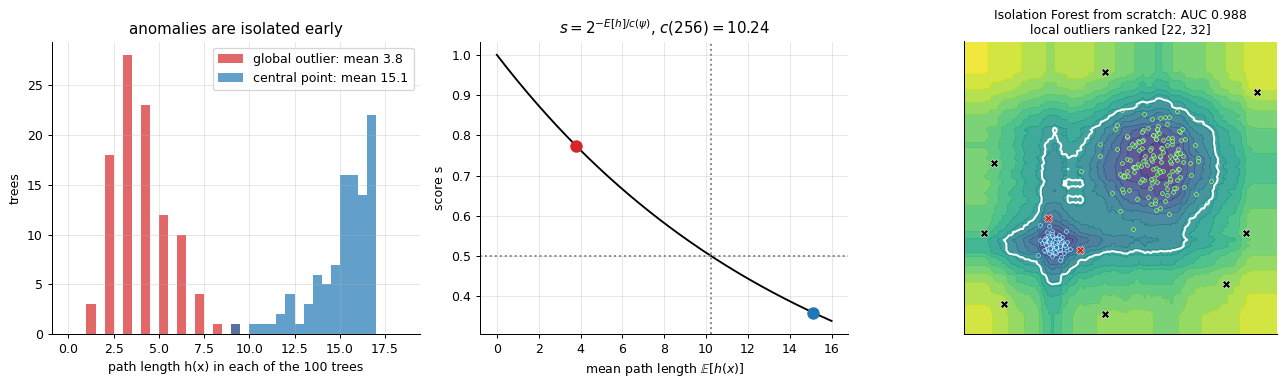

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), gridspec_kw={"width_ratios": [1, 1, 1.15]})
ax = axes[0]
bins = np.arange(0, 19, 0.5)
ax.hist(H2[:, i_out], bins=bins, color="tab:red", alpha=0.7, label=f"global outlier: mean {H2[:, i_out].mean():.1f}")
ax.hist(H2[:, i_in], bins=bins, color="tab:blue", alpha=0.7, label=f"central point: mean {H2[:, i_in].mean():.1f}")
ax.set_xlabel("path length h(x) in each of the 100 trees"); ax.set_ylabel("trees"); ax.legend(); ax.set_title("anomalies are isolated early")
ax = axes[1]
e = np.linspace(0, 16, 200); ax.plot(e, 2 ** (-e / c256), "k")
ax.axhline(0.5, color="gray", ls=":"); ax.axvline(c256, color="gray", ls=":")
for i, c in [(i_out, "tab:red"), (i_in, "tab:blue")]:
    ax.scatter(H2[:, i].mean(), s_ifs[i], s=80, c=c, zorder=3)
ax.set_xlabel(r"mean path length $\mathbb{E}[h(x)]$"); ax.set_ylabel("score s"); ax.set_title(r"$s = 2^{-E[h]/c(\psi)}$, $c(256) = 10.24$")
ax = axes[2]
S = ifs.score(G2)
score_map(ax, S, X2, g2, f"Isolation Forest from scratch: AUC {roc_auc_score(y2, s_ifs):.3f}\nlocal outliers ranked {rank_of(s_ifs, loc_idx)}",
          np.quantile(s_ifs, 1 - 10 / 310))
plt.tight_layout(); plt.show()

**What just happened?** The global outlier at (10, 7.5) was isolated after 3.8 cuts on average (score 0.773), while the central point of the dense cluster went down 15.1 levels on average (score 0.359, below 0.5). The score map shows the forest's signature: **axis-parallel** stripes and crosses, because every cut is perpendicular to an axis. The from-scratch forest and scikit-learn's agree closely (Spearman correlation 0.980; they use different random numbers).

Isolation Forest is a **global** method like the $k$-NN distance: it ranks the local outliers 22nd and 32nd, after the edge of the sparse cluster. Its strengths are elsewhere: it needs no distances (no scaling problem across features, mixed units are fine), it handles many features, and its cost does not grow with $n$.

**Extended Isolation Forest** (Hariri et al., 2019) cuts with random **hyperplanes** instead of axis-parallel ones, which removes the stripes and the artefacts along the axes.

Check the scaling claim: time to fit and score as $n$ grows, against LOF and the one-class SVM of the next section (10 features).

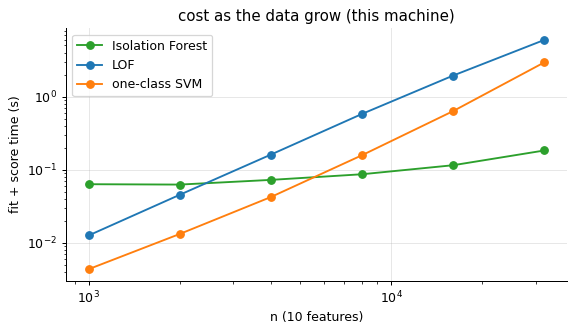

Isolation Forest    0.063    0.062    0.072    0.086    0.115    0.183  s
LOF                 0.013    0.045    0.160    0.578    1.937    5.953  s
one-class SVM       0.004    0.013    0.042    0.157    0.632    2.933  s


In [15]:
rng = np.random.default_rng(0)
sizes = [1000, 2000, 4000, 8000, 16000, 32000]
times = {"Isolation Forest": [], "LOF": [], "one-class SVM": []}
for n in sizes:
    Xs = rng.normal(size=(n, 10))
    t = time.time(); IsolationForest(n_estimators=100, random_state=0).fit(Xs).score_samples(Xs); times["Isolation Forest"].append(time.time() - t)
    t = time.time(); LocalOutlierFactor(n_neighbors=20).fit(Xs); times["LOF"].append(time.time() - t)
    if n <= 32000:
        t = time.time(); OneClassSVM(nu=0.05, gamma="scale").fit(Xs).decision_function(Xs); times["one-class SVM"].append(time.time() - t)
fig, ax = plt.subplots(figsize=(6.5, 3.8))
for (name, ts), c in zip(times.items(), ["tab:green", "tab:blue", "tab:orange"]):
    ax.loglog(sizes[:len(ts)], ts, "o-", color=c, label=name)
ax.set_xlabel("n (10 features)"); ax.set_ylabel("fit + score time (s)"); ax.legend(); ax.set_title("cost as the data grow (this machine)")
plt.tight_layout(); plt.show()
for name, ts in times.items():
    print(f"{name:17s}", "  ".join(f"{t:7.3f}" for t in ts), " s")

**Interpretation.** From 1,000 to 32,000 points the Isolation Forest goes from 0.06 s to 0.18 s: building the trees costs the same at every $n$ (each tree sees 256 points), only the scoring of every point grows, linearly. LOF goes from 0.01 s to 6.0 s and the one-class SVM from 0.004 s to 2.9 s: both are multiplied by 3 to 5 each time $n$ doubles (neighbour search in 10 dimensions; a kernel matrix that grows like $n^2$). Extrapolate to a million claims and only the Isolation Forest is still a matter of seconds.

## 7. One-class SVM

The SVM of the course separates two classes with a maximum margin. With one class, Schölkopf et al. (2001) separate the data **from the origin** in the kernel's feature space, with the largest margin $\rho/\lVert\mathbf{w}\rVert$:

$$
\min_{\mathbf{w},\,\boldsymbol\xi,\,\rho}\ \frac12\lVert\mathbf{w}\rVert^2 + \frac{1}{\nu n}\sum_{i=1}^n \xi_i - \rho
\quad\text{s.t.}\quad \mathbf{w}^\top\phi(\mathbf{x}_i) \ge \rho - \xi_i,\ \ \xi_i \ge 0 .
$$

The decision function is $f(\mathbf{x}) = \sum_i \alpha_i k(\mathbf{x}_i, \mathbf{x}) - \rho$: inside (normal) when $f \ge 0$. With the RBF kernel $k(\mathbf{x}, \mathbf{x}') = e^{-\gamma\lVert\mathbf{x}-\mathbf{x}'\rVert^2}$, $f$ is a sum of Gaussian bumps on the support vectors: a smoothed density, cut at the level $\rho$.

**The meaning of $\nu$.** The dual is $\min_{\boldsymbol\alpha} \frac12\sum_{ij}\alpha_i\alpha_j k(\mathbf{x}_i, \mathbf{x}_j)$ subject to $0 \le \alpha_i \le \frac{1}{\nu n}$ and $\sum_i \alpha_i = 1$.
- Points outside ($\xi_i > 0$) have $\alpha_i$ at its upper bound $\frac{1}{\nu n}$. Since the $\alpha$'s sum to 1, there are at most $\nu n$ of them: **$\nu$ is an upper bound on the fraction of outliers**.
- Support vectors have $\alpha_i > 0$, and each $\alpha_i \le \frac{1}{\nu n}$, so at least $\nu n$ of them are needed to reach a sum of 1: **$\nu$ is a lower bound on the fraction of support vectors**.

So $\nu$ is roughly the contamination you expect. **$\gamma$** sets the width of the bumps: small $\gamma$, one smooth blob; large $\gamma$, an island around every point (overfitting: every new point looks anomalous).

**SVDD** (Tax and Duin, 2004) instead finds the smallest ball enclosing most of the data in feature space. With the RBF kernel all $\phi(\mathbf{x})$ have norm 1 ($k(\mathbf{x}, \mathbf{x}) = 1$), they lie on a sphere, and the two formulations give the same solution.

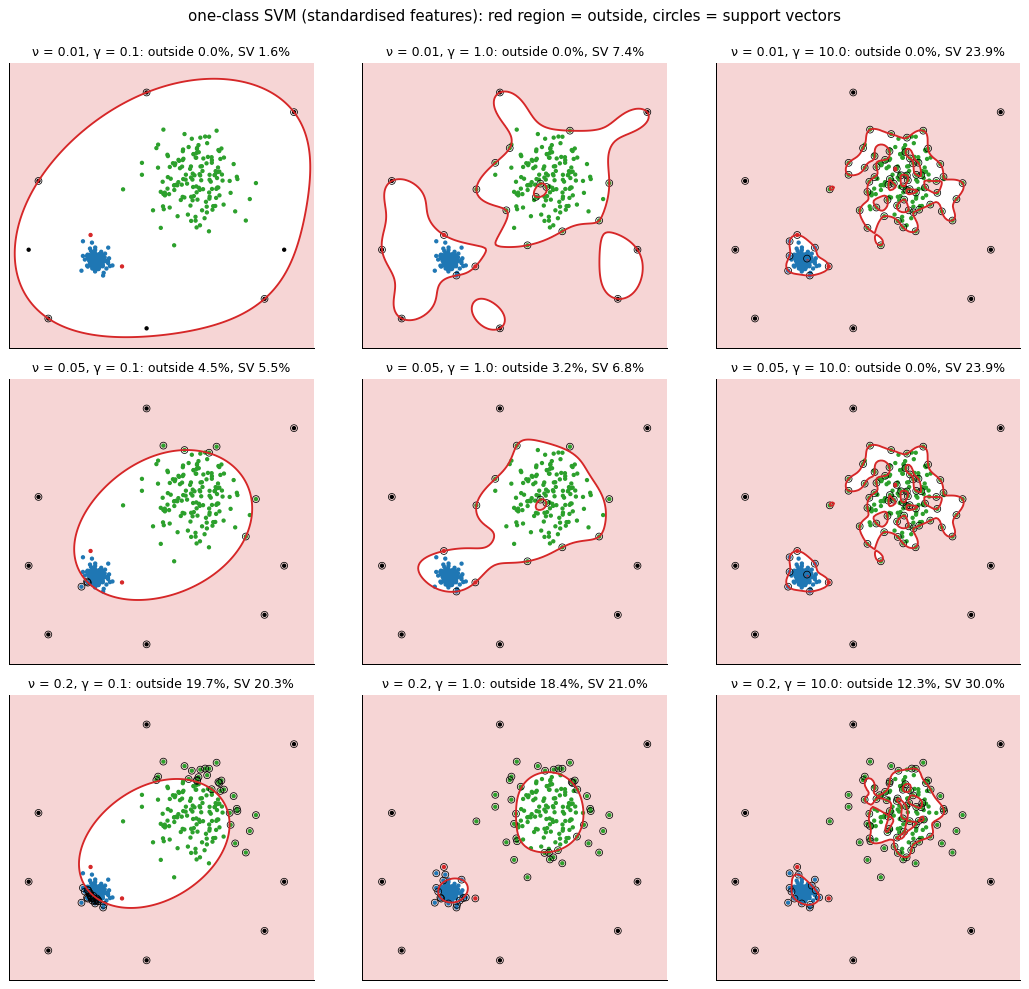

  nu  gamma  fraction outside  fraction SV   AUC
0.01    0.1             0.000        0.016 0.908
0.01    1.0             0.000        0.074 0.975
0.01   10.0             0.000        0.239 0.883
0.05    0.1             0.045        0.055 0.889
0.05    1.0             0.032        0.068 0.994
0.05   10.0             0.000        0.239 0.882
0.20    0.1             0.197        0.203 0.871
0.20    1.0             0.184        0.210 0.992
0.20   10.0             0.123        0.300 0.993


In [16]:
sc2 = StandardScaler().fit(X2); Z2 = sc2.transform(X2); GZ2 = sc2.transform(G2)
fig, axes = plt.subplots(3, 3, figsize=(12, 11))
rows = []
for a, nu in enumerate((0.01, 0.05, 0.2)):
    for b, gamma in enumerate((0.1, 1.0, 10.0)):
        oc = OneClassSVM(nu=nu, gamma=gamma, tol=1e-6).fit(Z2)      # tight tolerance: f is exact to ~1e-6
        f_tr = oc.decision_function(Z2)
        # outliers = strictly outside (xi_i > 0); margin support vectors sit exactly on the boundary, f = 0
        frac_out, frac_sv = np.mean(f_tr < -1e-6), len(oc.support_) / len(Z2)
        rows.append((nu, gamma, frac_out, frac_sv, roc_auc_score(y2, -f_tr)))
        assert frac_out <= nu <= frac_sv                                 # the nu-property
        ax = axes[a, b]; F = oc.decision_function(GZ2).reshape(gx.shape)
        ax.contourf(gx, gy, F, levels=[F.min(), 0], colors=["#f6d5d5"]); ax.contour(gx, gy, F, levels=[0], colors="tab:red", linewidths=1.5)
        ax.scatter(*X2.T, s=6, c=GCOL[g2]); ax.scatter(*X2[oc.support_].T, s=30, facecolors="none", edgecolors="k", linewidths=0.6)
        ax.set_title(f"ν = {nu}, γ = {gamma}: outside {frac_out:.1%}, SV {frac_sv:.1%}", fontsize=10)
        ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")
plt.suptitle("one-class SVM (standardised features): red region = outside, circles = support vectors", y=0.995)
plt.tight_layout(); plt.show()
print(pd.DataFrame(rows, columns=["nu", "gamma", "fraction outside", "fraction SV", "AUC"]).round(3).to_string(index=False))

**Interpretation.** In every panel the fraction of training points outside the boundary is at most $\nu$ and the fraction of support vectors at least $\nu$, as the dual proof says (for example $\nu = 0.05$, $\gamma = 1$: 3.2 % outside, 6.8 % support vectors). The kernel width matters as much as $\nu$: with $\gamma = 0.1$ the boundary is one smooth convex blob around both clusters (no notion of two densities); with $\gamma = 10$ it shrinks to islands around the points, and a quarter of the points become support vectors. In between ($\gamma = 1$) the boundary follows the two clusters. Like LOF and the $k$-NN distance it depends on the scaling of the features, and there is no label-free way to tune $\gamma$: in practice, use the median heuristic ($\gamma = 1/(d\,\operatorname{Var})$, scikit-learn's `gamma="scale"`) and check on a few labelled anomalies.

## 8. All methods on three 2-D data sets

Same five detectors, three shapes of normal data: the two densities with local and global outliers, two **moons** (a non-convex shape) with uniform outliers, and one **correlated Gaussian** with outliers that break the correlation (each feature alone is ordinary). Colour = the score as a percentile of the training scores (same colour, same rank), white contour = the threshold that flags as many points as there are anomalies.

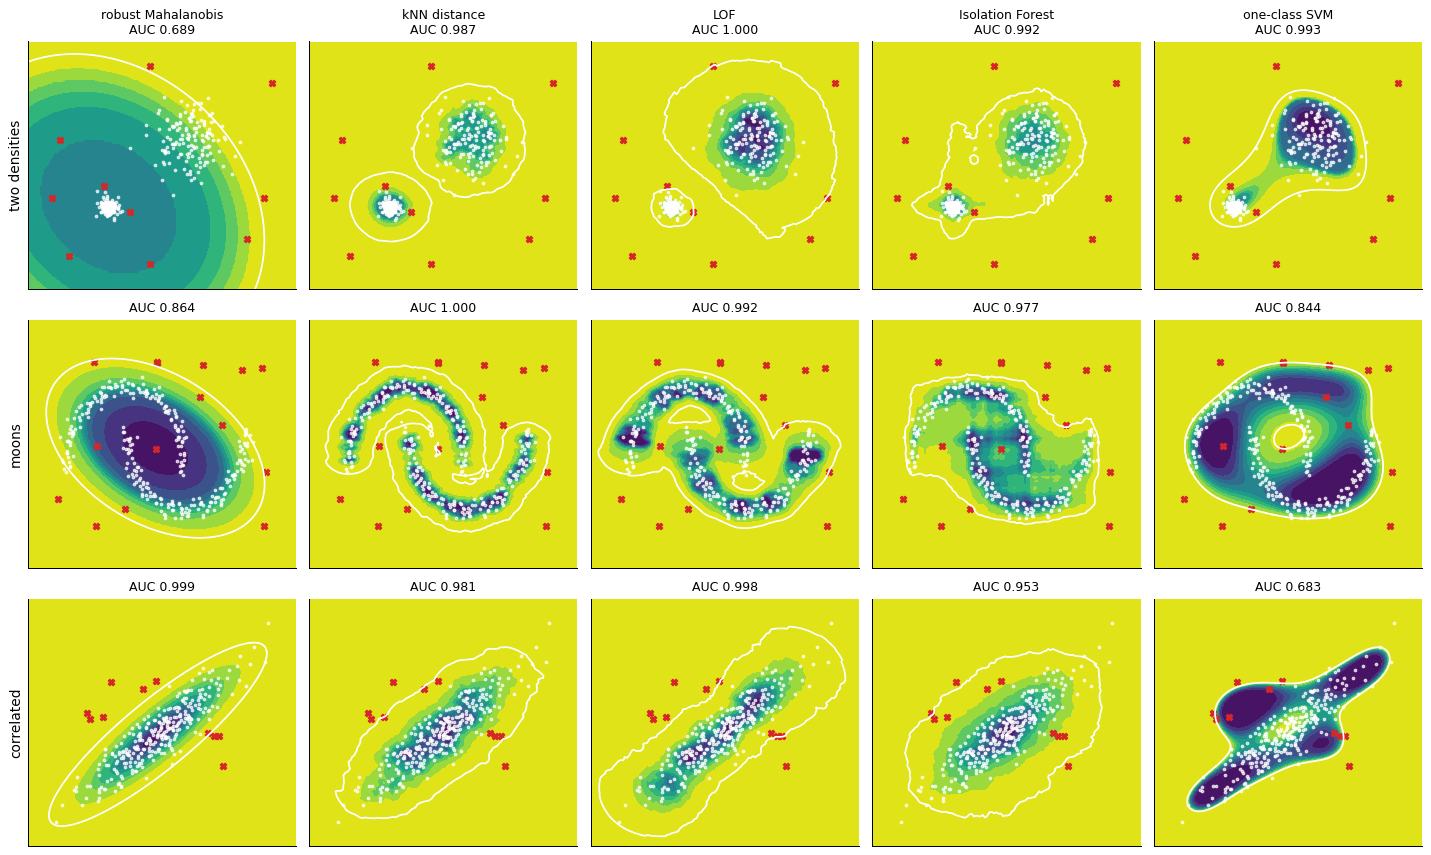

               Isolation Forest    LOF  kNN distance  one-class SVM  robust Mahalanobis
correlated                0.953  0.998         0.981          0.683               0.999
moons                     0.977  0.992         1.000          0.844               0.864
two densities             0.992  1.000         0.987          0.993               0.689


In [17]:
def make_moons_out(seed=4):
    rng = np.random.default_rng(seed)
    Xm, _ = make_moons(300, noise=0.06, random_state=seed)
    Xm = Xm * 3 + [0.0, 1.5]
    out = rng.uniform(Xm.min(0) - 0.8, Xm.max(0) + 0.8, size=(400, 2))              # many fall inside the bends
    keep = np.min(np.linalg.norm(out[:, None] - Xm[None], axis=2), axis=1) > 0.8       # not on the moons
    out = out[keep][:15]
    return np.vstack([Xm, out]), np.r_[np.zeros(300), np.ones(len(out))].astype(int)

def make_corr_out(seed=5):
    rng = np.random.default_rng(seed)
    Xc = rng.multivariate_normal([3, 2], [[4.0, 3.6], [3.6, 4.0]], size=300)
    ang = rng.uniform(0, 2 * np.pi, 10); r = rng.uniform(1.6, 2.6, 10)
    out = np.c_[3 + r * np.cos(ang) * 1.0, 2 + r * np.sin(ang) * 1.0]
    out = out + np.outer(np.sign(np.sin(ang - np.pi / 4)) * 1.6, [-1, 1]) / np.sqrt(2)  # push away from the diagonal
    return np.vstack([Xc, out]), np.r_[np.zeros(300), np.ones(10)].astype(int)

DATASETS = {"two densities": (X2, y2), "moons": make_moons_out(), "correlated": make_corr_out()}

def all_scores(X_fit, X_eval):
    # returns {method: (train scores, grid scores)}, higher = more anomalous; distance methods on standardised data
    sc = StandardScaler().fit(X_fit); Z, ZG = sc.transform(X_fit), sc.transform(X_eval)
    out = {}
    mcd_ = MinCovDet(random_state=0).fit(Z); out["robust Mahalanobis"] = (mcd_.mahalanobis(Z), mcd_.mahalanobis(ZG))
    nn_ = NearestNeighbors(n_neighbors=11).fit(Z)
    out["kNN distance"] = (nn_.kneighbors(Z)[0][:, 10], nn_.kneighbors(ZG, n_neighbors=10)[0][:, 9])
    out["LOF"] = (-LocalOutlierFactor(20).fit(Z).negative_outlier_factor_, -LocalOutlierFactor(20, novelty=True).fit(Z).score_samples(ZG))
    iso_ = IsolationForest(n_estimators=200, random_state=0).fit(X_fit); out["Isolation Forest"] = (-iso_.score_samples(X_fit), -iso_.score_samples(X_eval))
    oc_ = OneClassSVM(nu=0.05, gamma="scale").fit(Z); out["one-class SVM"] = (-oc_.decision_function(Z), -oc_.decision_function(ZG))
    return out

fig, axes = plt.subplots(3, 5, figsize=(16, 9.6))
auc_grid = {}
for r, (dname, (X, y)) in enumerate(DATASETS.items()):
    lo_, hi_ = X.min(0) - 1.5, X.max(0) + 1.5
    ax_, ay_ = np.meshgrid(np.linspace(lo_[0], hi_[0], 120), np.linspace(lo_[1], hi_[1], 110)); G = np.c_[ax_.ravel(), ay_.ravel()]
    for c, (mname, (s_tr, s_g)) in enumerate(all_scores(X, G).items()):
        pct = np.searchsorted(np.sort(s_tr), s_g) / len(s_tr)                  # grid score as a percentile of the training scores
        thr_ = np.quantile(s_tr, 1 - y.mean())
        auc_grid[(dname, mname)] = roc_auc_score(y, s_tr)
        ax = axes[r, c]
        ax.contourf(ax_, ay_, pct.reshape(ax_.shape), levels=np.linspace(0, 1, 11), cmap="viridis")
        ax.contour(ax_, ay_, s_g.reshape(ax_.shape), levels=[thr_], colors="white", linewidths=1.4)
        ax.scatter(*X[y == 0].T, s=4, c="white", alpha=0.7); ax.scatter(*X[y == 1].T, s=26, c="tab:red", marker="X")
        ax.set_xticks([]); ax.set_yticks([]); ax.set_title(f"{mname}\nAUC {auc_grid[(dname, mname)]:.3f}" if r == 0 else f"AUC {auc_grid[(dname, mname)]:.3f}", fontsize=10)
        if c == 0:
            ax.set_ylabel(dname, fontsize=11)
plt.tight_layout(); plt.show()
print(pd.Series(auc_grid).unstack().round(3).to_string())

**Things to notice.**
- **No method wins everywhere.** The robust Mahalanobis distance is the best on the correlated Gaussian (0.999) and the worst on the two densities (0.689); the one-class SVM is among the best on the two densities (0.993) and the worst on the correlated data (0.683); the $k$-NN distance is perfect on the moons and LOF is never below 0.99.
- The **robust Mahalanobis** distance draws one ellipse whatever the data: perfect for the correlated Gaussian (it is the right model), useless for the shape of the moons and for two clusters of different density.
- The **$k$-NN distance** and the **one-class SVM** follow any shape but are global: one density level for the whole plane. **LOF** is the only local score; it pays for it with a noisier map where the data are sparse.
- The one-class SVM's values **inside** its boundary are not a density: $f$ is a sum of bumps on the support vectors, which sit on the edge of the data, so the "most normal" regions (dark) can be near the edges and the centre can score higher (correlated data). Its boundary is meaningful; its ranking far from the boundary is not.
- The **Isolation Forest** is never the best and never bad, with its axis-parallel artefacts: the reason it is the default first try on tabular data.

## 9. A real benchmark: Satellite

**Satellite** (Goldstein and Uchida, 2016) comes from the Landsat images of the UCI *Statlog* data: each row is a 3 × 3 pixel patch seen in 4 spectral bands, so 36 features. The four soil classes are the normal data; the anomalies are a small random sample of the "cotton crop" and "vegetation stubble" patches. We download it from OpenML (about 0.5 MB) and use it as an **unsupervised** problem: every detector sees all the rows without labels, and the labels are used only to evaluate.

**Metrics for a ranking.** A detector produces a ranking; the labels say where the anomalies ended up in it.
- **ROC-AUC**: the probability that a random anomaly scores higher than a random normal point. It does not depend on the base rate.
- **Average precision (AP)**, the area under the precision–recall curve: $\text{AP} = \sum_j (R_j - R_{j-1})\,P_j$ over the thresholds $j$. A random ranking has $\text{AP} = \pi$, so always compare AP with the base rate.
- **Precision@$k$**: the fraction of anomalies among the $k$ highest scores, what an investigator who reviews $k$ alerts sees. With $k$ equal to the number of anomalies it is called R-precision.

In [18]:
sat = fetch_openml(data_id=40900, data_home="data/openml", as_frame=True, parser="auto")
X_sat = StandardScaler().fit_transform(sat.data.to_numpy(float))       # distances need comparable scales
y_sat = (sat.target.astype(str) == "Anomaly").to_numpy().astype(int)
pi_sat = y_sat.mean()
print(f"Satellite: {X_sat.shape[0]} rows, {X_sat.shape[1]} features, {y_sat.sum()} anomalies -> base rate {pi_sat:.2%}")

def precision_at_k(y, s, k):
    return y[np.argsort(-s, kind="stable")[:k]].mean()

def pca_error_fit(X, k):
    p = PCA(n_components=k, random_state=0).fit(X)
    return ((X - p.inverse_transform(p.transform(X))) ** 2).sum(1)

DETECTORS = {
    "Mahalanobis": lambda X: EmpiricalCovariance().fit(X).mahalanobis(X),
    "robust Mahalanobis (MCD)": lambda X: MinCovDet(random_state=0).fit(X).mahalanobis(X),
    "kNN distance (k=10)": lambda X: NearestNeighbors(n_neighbors=11).fit(X).kneighbors(X)[0][:, 10],
    "LOF (k=20)": lambda X: -LocalOutlierFactor(n_neighbors=20).fit(X).negative_outlier_factor_,
    "Isolation Forest": lambda X: -IsolationForest(n_estimators=200, random_state=0).fit(X).score_samples(X),
    "one-class SVM (nu=0.05)": lambda X: -OneClassSVM(nu=0.05, gamma="scale").fit(X).decision_function(X),
    "GMM (5 comp.), -log p": lambda X: -GaussianMixture(5, random_state=0).fit(X).score_samples(X),
    "PCA error (12 comp.)": lambda X: pca_error_fit(X, 12),
}
S_sat, rows = {}, []
for name, f in DETECTORS.items():
    t = time.time(); S_sat[name] = f(X_sat); dt = time.time() - t
    rows.append((name, roc_auc_score(y_sat, S_sat[name]), average_precision_score(y_sat, S_sat[name]),
                 precision_at_k(y_sat, S_sat[name], 75), precision_at_k(y_sat, S_sat[name], 100), dt))
# ensembles: the scores live on different scales, so normalise them (ranks or z-scores) before averaging
print("score ranges:", "; ".join(f"{k} {v.min():.3g} to {v.max():.3g}" for k, v in list(S_sat.items())[2:6]))
rank_norm = lambda s: stats.rankdata(s) / len(s)
z_norm = lambda s: (s - s.mean()) / s.std()
THREE = ["kNN distance (k=10)", "Isolation Forest", "one-class SVM (nu=0.05)"]   # distance, isolation, boundary
ENS = {"ensemble of 3: mean z": (THREE, z_norm), "ensemble of 3: mean rank": (THREE, rank_norm),
       "ensemble of all 8: mean z": (list(DETECTORS), z_norm), "ensemble of all 8: mean rank": (list(DETECTORS), rank_norm)}
for name, (members, norm) in ENS.items():
    S_sat[name] = np.mean([norm(S_sat[m]) for m in members], axis=0)
for name in ENS:
    rows.append((name, roc_auc_score(y_sat, S_sat[name]), average_precision_score(y_sat, S_sat[name]),
                 precision_at_k(y_sat, S_sat[name], 75), precision_at_k(y_sat, S_sat[name], 100), np.nan))
res_sat = pd.DataFrame(rows, columns=["detector", "ROC-AUC", "AP", "P@75", "P@100", "time (s)"]).set_index("detector")
print(res_sat.round(3).to_string())
print(f"\nrandom ranking: ROC-AUC 0.5, AP = base rate = {pi_sat:.3f}, P@k = {pi_sat:.3f}")

Satellite: 5100 rows, 36 features, 75 anomalies -> base rate 1.47%


score ranges: kNN distance (k=10) 1.02 to 9.18; LOF (k=20) 0.968 to 2.9; Isolation Forest 0.395 to 0.754; one-class SVM (nu=0.05) -16.5 to 24.7
                              ROC-AUC     AP   P@75  P@100  time (s)
detector                                                            
Mahalanobis                     0.914  0.379  0.413   0.34     0.003
robust Mahalanobis (MCD)        0.960  0.578  0.520   0.39     1.177
kNN distance (k=10)             0.974  0.527  0.493   0.42     0.028
LOF (k=20)                      0.676  0.187  0.253   0.22     0.031
Isolation Forest                0.947  0.644  0.627   0.50     0.144
one-class SVM (nu=0.05)         0.890  0.602  0.547   0.46     0.084
GMM (5 comp.), -log p           0.939  0.146  0.173   0.19     0.067
PCA error (12 comp.)            0.840  0.174  0.240   0.24     0.001
ensemble of 3: mean z           0.958  0.653  0.573   0.48       NaN
ensemble of 3: mean rank        0.952  0.645  0.600   0.47       NaN
ensemble of all 8: mean z   

GMM (5 comp.), -log p    ROC-AUC 0.939 | to catch 60 of 75 anomalies:   482 alerts,   422 false alarms, precision 12.4%, FPR 8.4%
kNN distance (k=10)      ROC-AUC 0.974 | to catch 60 of 75 anomalies:   275 alerts,   215 false alarms, precision 21.8%, FPR 4.3%
Isolation Forest         ROC-AUC 0.947 | to catch 60 of 75 anomalies:   424 alerts,   364 false alarms, precision 14.2%, FPR 7.2%


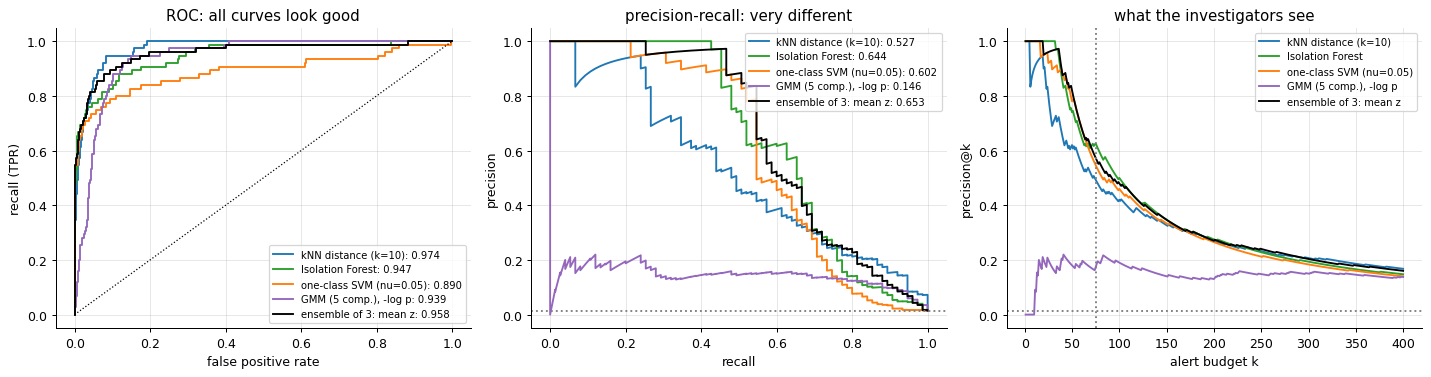

In [19]:
def flagged_for_recall(y, s, recall):
    # smallest number of alerts that catches the given fraction of the anomalies
    order = np.argsort(-s, kind="stable"); tp = np.cumsum(y[order])
    k = int(np.searchsorted(tp, np.ceil(recall * y.sum())) + 1)
    return k, tp[k - 1]

for name in ["GMM (5 comp.), -log p", "kNN distance (k=10)", "Isolation Forest"]:
    k80, tp80 = flagged_for_recall(y_sat, S_sat[name], 0.8)
    print(f"{name:24s} ROC-AUC {res_sat.loc[name, 'ROC-AUC']:.3f} | to catch {tp80} of 75 anomalies: {k80:5d} alerts, "
          f"{k80 - tp80:5d} false alarms, precision {tp80 / k80:.1%}, FPR {(k80 - tp80) / (y_sat == 0).sum():.1%}")

show = ["kNN distance (k=10)", "Isolation Forest", "one-class SVM (nu=0.05)", "GMM (5 comp.), -log p", "ensemble of 3: mean z"]
cols = ["tab:blue", "tab:green", "tab:orange", "tab:purple", "k"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
for name, c in zip(show, cols):
    fpr_, tpr_, _ = roc_curve(y_sat, S_sat[name]); pr_, rc_, _ = precision_recall_curve(y_sat, S_sat[name])
    axes[0].plot(fpr_, tpr_, color=c, label=f"{name}: {res_sat.loc[name, 'ROC-AUC']:.3f}")
    axes[1].plot(rc_, pr_, color=c, label=f"{name}: {res_sat.loc[name, 'AP']:.3f}")
    ks = np.arange(1, 401); hits = np.cumsum(y_sat[np.argsort(-S_sat[name], kind="stable")])[:400]
    axes[2].plot(ks, hits / ks, color=c, label=name)
axes[0].plot([0, 1], [0, 1], "k:", lw=1); axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("recall (TPR)")
axes[0].set_title("ROC: all curves look good"); axes[0].legend(fontsize=8, loc="lower right")
axes[1].axhline(pi_sat, color="gray", ls=":"); axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title("precision-recall: very different"); axes[1].legend(fontsize=8, loc="upper right")
axes[2].axvline(75, color="gray", ls=":"); axes[2].axhline(pi_sat, color="gray", ls=":")
axes[2].set_xlabel("alert budget k"); axes[2].set_ylabel("precision@k"); axes[2].set_title("what the investigators see"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

**What just happened?**
- On a ROC plot every detector looks good: the ROC-AUCs lie between 0.84 and 0.97, except LOF (0.676), whose local view does not suit these data. The precision–recall plot and precision@$k$ tell a different story: AP ranges from 0.146 (GMM) to 0.644 (Isolation Forest), against 0.015 for a random ranking.
- **The base-rate lesson in numbers.** The Gaussian mixture has ROC-AUC 0.939. To catch 80 % of the anomalies (60 of 75) it must raise 482 alerts, 422 of them false: a precision of 12.4 %, with a false positive rate of only 8.4 %. An FPR of 8.4 % sounds small, and ROC-AUC rewards it; but 8.4 % of 5,025 normal points is 422 false alarms against 60 true ones. The $k$-NN distance needs 275 alerts for the same recall (precision 21.8 %).
- **The ranking of the detectors depends on the metric.** By ROC-AUC the best is the $k$-NN distance (0.974); by AP and P@75 it is the Isolation Forest (0.644 and 0.627: of its 75 highest scores, 47 are anomalies). When investigators review the top of the list, AP and P@$k$ are the metrics that matter.
- **Ensembles.** The raw scores live on unrelated scales (the one-class SVM's from $-16.5$ to $24.7$, the Isolation Forest's from 0.40 to 0.75), so normalise first. The mean z-score of three detectors built on different principles (distance, isolation, boundary) reaches AP 0.653, above each of its members, without knowing in advance which one works best here. Averaging all eight is worse (AP 0.488 with z-scores, 0.222 with ranks): weak members drag the top of the ranking down, and ranks flatten the extremes (a point that one detector puts first and the others put in the middle ends in the middle). Choose the members, normalise, then average.
- **Robust vs classical Mahalanobis**: MCD gives AP 0.578 against 0.379. Even 1.5 % of anomalies distort a 36-dimensional covariance enough to matter.

**How much can a few labels tell you?** Often only a handful of confirmed anomalies exist. Simulate it: keep all normal points but only $m$ random anomalies, compute the AUC, repeat.

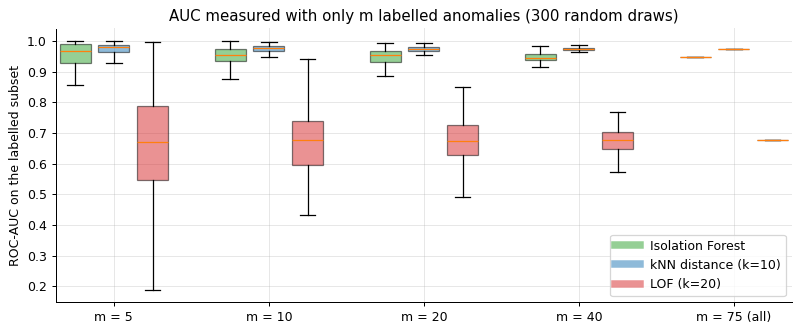

m =  5: Isolation Forest AUC 90% range [0.823, 0.999];  IF ranked above kNN in 34% of the draws;  LOF ranked last in 94%
m = 10: Isolation Forest AUC 90% range [0.877, 0.992];  IF ranked above kNN in 18% of the draws;  LOF ranked last in 99%
m = 20: Isolation Forest AUC 90% range [0.900, 0.983];  IF ranked above kNN in 8% of the draws;  LOF ranked last in 100%
m = 40: Isolation Forest AUC 90% range [0.925, 0.969];  IF ranked above kNN in 0% of the draws;  LOF ranked last in 100%


In [20]:
rng = np.random.default_rng(0)
anom_idx, norm_idx = np.flatnonzero(y_sat == 1), np.flatnonzero(y_sat == 0)
ms = [5, 10, 20, 40, 75]
pair = ["Isolation Forest", "kNN distance (k=10)", "LOF (k=20)"]
sims = {name: {m: [] for m in ms} for name in pair}
for m in ms:
    for rep in range(300 if m < 75 else 1):
        sub = np.r_[norm_idx, rng.choice(anom_idx, m, replace=False)]
        for name in pair:
            sims[name][m].append(roc_auc_score(y_sat[sub], S_sat[name][sub]))
fig, ax = plt.subplots(figsize=(9, 3.8))
for j, (name, c) in enumerate(zip(pair, ["tab:green", "tab:blue", "tab:red"])):
    pos = np.arange(len(ms)) * 4 + j
    bp = ax.boxplot([sims[name][m] for m in ms], positions=pos, widths=0.8, patch_artist=True, showfliers=False)
    for b in bp["boxes"]:
        b.set_facecolor(c); b.set_alpha(0.5)
    ax.plot([], [], color=c, lw=6, alpha=0.5, label=name)
ax.set_xticks(np.arange(len(ms)) * 4 + 1, [f"m = {m}" for m in ms[:-1]] + ["m = 75 (all)"]); ax.set_ylabel("ROC-AUC on the labelled subset")
ax.set_title("AUC measured with only m labelled anomalies (300 random draws)"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()
for m in ms[:-1]:
    a, b = np.array(sims["Isolation Forest"][m]), np.array(sims["kNN distance (k=10)"][m])
    lo_, hi_ = np.percentile(a, [5, 95])
    print(f"m = {m:2d}: Isolation Forest AUC 90% range [{lo_:.3f}, {hi_:.3f}];  IF ranked above kNN in {np.mean(a > b):.0%} of the draws;"
          f"  LOF ranked last in {np.mean(np.array(sims['LOF (k=20)'][m]) < np.minimum(a, b)):.0%}")

**Interpretation.** With all 75 anomalies the $k$-NN distance beats the Isolation Forest by a small margin. With only 10 labelled anomalies, the Isolation Forest's AUC could be anywhere in [0.877, 0.992] (90 % of the draws), and the order of the two detectors flips in 18 % of the draws: a handful of labels **cannot rank two good detectors**. But it is enough to catch a bad one: LOF comes out last in 99 % of the draws already with $m = 10$. So: always evaluate on whatever labelled anomalies exist (past confirmed frauds, even a few), report the uncertainty, and use them to reject detectors and to choose a threshold, not to declare a winner by 0.01 of AUC.

## 10. Reconstruction error: PCA and an autoencoder on MNIST

Another way to define "normal": normal data live near a **low-dimensional structure** inside the feature space. Learn a map that compresses and reconstructs, $\mathbf{x} \mapsto \hat{\mathbf{x}}$, on normal data only. Normal inputs are reconstructed well; inputs that do not share the structure are not. The score is the **reconstruction error** $s(\mathbf{x}) = \lVert \mathbf{x} - \hat{\mathbf{x}} \rVert^2$ (here averaged over the pixels).

- **PCA**: keep the top $k$ principal directions $\mathbf{V}_k$ (columns orthonormal) of the centred normal data. $\hat{\mathbf{x}} = \boldsymbol\mu + \mathbf{V}_k\mathbf{V}_k^\top(\mathbf{x} - \boldsymbol\mu)$, and the error is the squared distance from $\mathbf{x}$ to the $k$-dimensional affine subspace. It catches points that **break the correlations** (a residual off the subspace), even when no single feature is extreme.
- **Autoencoder** (Extra 3): an encoder to a small code, a decoder back, trained to minimise $\lVert \mathbf{x} - \hat{\mathbf{x}} \rVert^2$ on normal data. A non-linear PCA: the "subspace" becomes a curved manifold.

This is **novelty detection**: the training data are clean. Normal = handwritten **eights**: 5,851 training images, of which we keep 10 % aside to set the threshold. The test set mixes the 974 test eights with 108 other digits (10 % anomalies), and we also measure the AUC against each other digit separately on the full test set.

In [21]:
mn_tr = datasets.MNIST("data", train=True, download=True)
mn_te = datasets.MNIST("data", train=False, download=True)
Xtr_m = mn_tr.data.numpy().reshape(-1, 784).astype(np.float32) / 255; ytr_m = mn_tr.targets.numpy()
Xte_m = mn_te.data.numpy().reshape(-1, 784).astype(np.float32) / 255; yte_m = mn_te.targets.numpy()
NORMAL = 8
rng = np.random.default_rng(0)
idx8 = rng.permutation(np.flatnonzero(ytr_m == NORMAL)); n_val = len(idx8) // 10
X8_val, X8_fit = Xtr_m[idx8[:n_val]], Xtr_m[idx8[n_val:]]
te8 = np.flatnonzero(yte_m == NORMAL)
oth = rng.choice(np.flatnonzero(yte_m != NORMAL), round(len(te8) / 9), replace=False)
idx10 = np.r_[te8, oth]; X_te10, d_te10 = Xte_m[idx10], yte_m[idx10]; y_te10 = (d_te10 != NORMAL).astype(int)
print(f"normal = digit {NORMAL}: {len(X8_fit)} for fitting, {len(X8_val)} for the threshold;  "
      f"test: {len(te8)} eights + {len(oth)} other digits = {y_te10.mean():.1%} anomalies")

# PCA from scratch: SVD of the centred normal data
mu8 = X8_fit.mean(0)
_, sv8, Vt8 = np.linalg.svd(X8_fit - mu8, full_matrices=False)
def pca_error(X, k):
    C = X - mu8
    return ((C - C @ Vt8[:k].T @ Vt8[:k]) ** 2).mean(1)
p16 = PCA(16, svd_solver="full").fit(X8_fit)
assert np.allclose(pca_error(X_te10, 16), ((X_te10 - p16.inverse_transform(p16.transform(X_te10))) ** 2).mean(1), atol=1e-5)
print(f"16 components keep {np.sum(sv8[:16] ** 2) / np.sum(sv8 ** 2):.1%} of the variance of the eights;  from scratch == sklearn: True")
y_full = (yte_m != NORMAL).astype(int)
for kk in (1, 4, 16, 64, 256):
    print(f"PCA with k = {kk:3d}: AUC (eights vs all other test digits) {roc_auc_score(y_full, pca_error(Xte_m, kk)):.3f}")

normal = digit 8: 5266 for fitting, 585 for the threshold;  test: 974 eights + 108 other digits = 10.0% anomalies


16 components keep 60.2% of the variance of the eights;  from scratch == sklearn: True
PCA with k =   1: AUC (eights vs all other test digits) 0.854
PCA with k =   4: AUC (eights vs all other test digits) 0.821
PCA with k =  16: AUC (eights vs all other test digits) 0.861
PCA with k =  64: AUC (eights vs all other test digits) 0.811
PCA with k = 256: AUC (eights vs all other test digits) 0.792


autoencoder 784-128-16-128-784, 205,856 parameters, 20 epochs in 1.2 s; final training MSE 0.0226
threshold tau = 95th percentile of the validation errors = 0.0420
on the test set: 115 alerts, precision 59.1%, recall 63.0%, false alarm rate on eights 4.8% (target 5 %)
AUC on the 10 % test set: autoencoder 0.919   PCA(16) 0.891


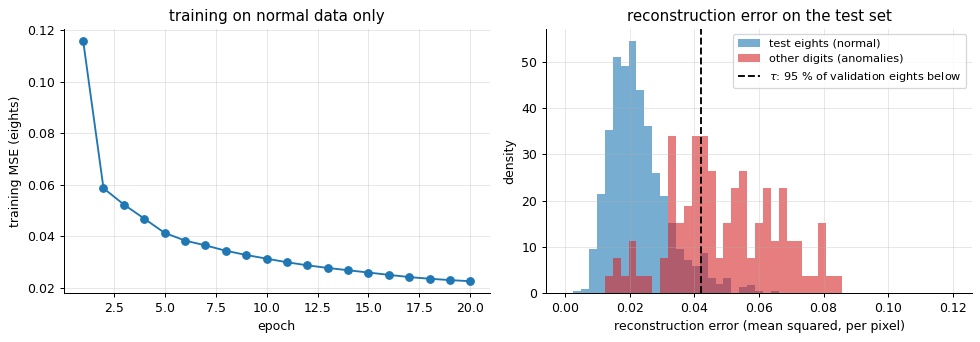

In [22]:
torch.manual_seed(0)
class AE(nn.Module):
    def __init__(self, d_code=16):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, d_code))
        self.dec = nn.Sequential(nn.ReLU(), nn.Linear(d_code, 128), nn.ReLU(), nn.Linear(128, 784), nn.Sigmoid())
    def forward(self, x):
        return self.dec(self.enc(x))

ae = AE().to(device)
opt = torch.optim.Adam(ae.parameters(), lr=1e-3)
Xf = torch.tensor(X8_fit, device=device)
losses = []
t0 = time.time()
for epoch in range(20):
    perm = torch.randperm(len(Xf), device=device); tot = 0.0
    for i in range(0, len(Xf), 128):
        xb = Xf[perm[i:i + 128]]
        loss = ((ae(xb) - xb) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step(); tot += loss.item() * len(xb)
    losses.append(tot / len(Xf))
print(f"autoencoder 784-128-16-128-784, {sum(p.numel() for p in ae.parameters()):,} parameters, 20 epochs in {time.time() - t0:.1f} s; "
      f"final training MSE {losses[-1]:.4f}")

@torch.no_grad()
def ae_error(X):
    xt = torch.tensor(X, device=device)
    return ((ae(xt) - xt) ** 2).mean(1).cpu().numpy()

err_val, err_te10, err_full = ae_error(X8_val), ae_error(X_te10), ae_error(Xte_m)
tau = np.quantile(err_val, 0.95)                    # threshold: 5 % false alarms on clean validation eights
flag = err_te10 > tau
tp_, fp_ = np.sum(flag & (y_te10 == 1)), np.sum(flag & (y_te10 == 0))
print(f"threshold tau = 95th percentile of the validation errors = {tau:.4f}")
print(f"on the test set: {flag.sum()} alerts, precision {tp_ / flag.sum():.1%}, recall {tp_ / y_te10.sum():.1%}, "
      f"false alarm rate on eights {fp_ / (y_te10 == 0).sum():.1%} (target 5 %)")
print(f"AUC on the 10 % test set: autoencoder {roc_auc_score(y_te10, err_te10):.3f}   PCA(16) {roc_auc_score(y_te10, pca_error(X_te10, 16)):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
axes[0].plot(np.arange(1, 21), losses, "o-"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("training MSE (eights)"); axes[0].set_title("training on normal data only")
bins = np.linspace(0, 0.12, 50)
axes[1].hist(err_te10[y_te10 == 0], bins=bins, alpha=0.6, density=True, label="test eights (normal)")
axes[1].hist(err_te10[y_te10 == 1], bins=bins, alpha=0.6, density=True, color="tab:red", label="other digits (anomalies)")
axes[1].axvline(tau, color="k", ls="--", label=r"$\tau$: 95 % of validation eights below")
axes[1].set_xlabel("reconstruction error (mean squared, per pixel)"); axes[1].set_ylabel("density"); axes[1].legend(fontsize=9)
axes[1].set_title("reconstruction error on the test set"); plt.tight_layout(); plt.show()

                    0      1      2      3      4      5      6      7      9
PCA (16)        0.988  0.404  0.958  0.898  0.942  0.875  0.956  0.931  0.863
autoencoder     0.995  0.463  0.978  0.934  0.967  0.941  0.971  0.958  0.930
AE error / ink  0.975  0.893  0.975  0.933  0.985  0.950  0.963  0.977  0.952

all other digits: PCA 0.861  AE 0.897  AE error / ink 0.955
mean error: test eights 0.0229, ones 0.0213;  mean ink: eights 0.153, ones 0.077


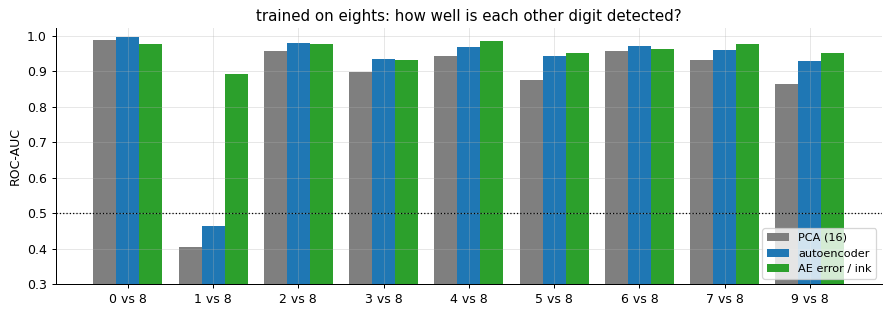

In [23]:
ink = Xte_m.mean(1)                                  # how much ink the digit uses
s_ae, s_pca, s_ae_c = err_full, pca_error(Xte_m, 16), err_full / ink
digit_auc = {}
for dgt in range(10):
    if dgt == NORMAL:
        continue
    m = (yte_m == NORMAL) | (yte_m == dgt); yy = (yte_m[m] == dgt).astype(int)
    digit_auc[dgt] = (roc_auc_score(yy, s_pca[m]), roc_auc_score(yy, s_ae[m]), roc_auc_score(yy, s_ae_c[m]))
DA = pd.DataFrame(digit_auc, index=["PCA (16)", "autoencoder", "AE error / ink"]).T
print(DA.round(3).T.to_string())
print(f"\nall other digits: PCA {roc_auc_score(y_full, s_pca):.3f}  AE {roc_auc_score(y_full, s_ae):.3f}  AE error / ink {roc_auc_score(y_full, s_ae_c):.3f}")
print(f"mean error: test eights {s_ae[yte_m == NORMAL].mean():.4f}, ones {s_ae[yte_m == 1].mean():.4f};  "
      f"mean ink: eights {ink[yte_m == NORMAL].mean():.3f}, ones {ink[yte_m == 1].mean():.3f}")

fig, ax = plt.subplots(figsize=(10, 3.6))
w = 0.27
for j, (col, c) in enumerate(zip(DA.columns, ["tab:gray", "tab:blue", "tab:green"])):
    ax.bar(np.arange(9) + (j - 1) * w, DA[col], w, color=c, label=col)
ax.axhline(0.5, color="k", ls=":", lw=1); ax.set_xticks(np.arange(9), [f"{d} vs 8" for d in DA.index]); ax.set_ylim(0.3, 1.02)
ax.set_ylabel("ROC-AUC"); ax.set_title("trained on eights: how well is each other digit detected?"); ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

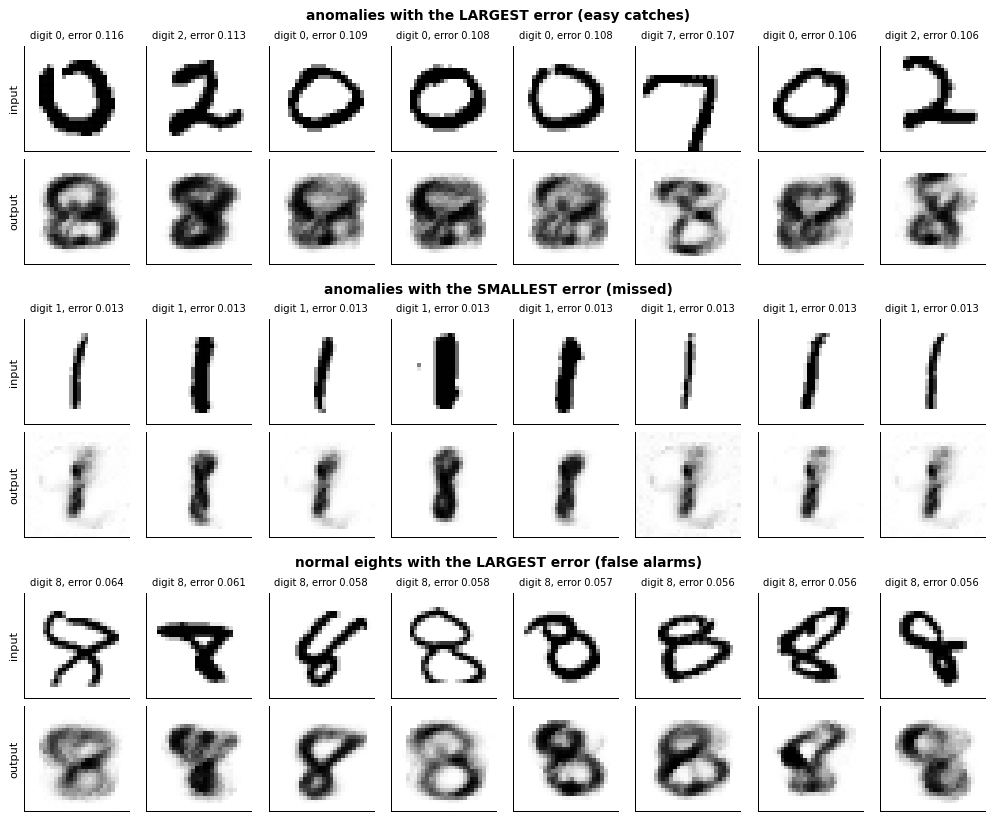

digits among the 50 anomalies with the smallest error: [ 0 50  0  0  0  0  0  0  0  0]


In [24]:
@torch.no_grad()
def recon(X):
    return ae(torch.tensor(X, device=device)).cpu().numpy()

an = np.flatnonzero(y_full == 1); no = np.flatnonzero(y_full == 0)
groups = [("anomalies with the LARGEST error (easy catches)", an[np.argsort(-s_ae[an])[:8]]),
          ("anomalies with the SMALLEST error (missed)", an[np.argsort(s_ae[an])[:8]]),
          ("normal eights with the LARGEST error (false alarms)", no[np.argsort(-s_ae[no])[:8]])]
fig = plt.figure(figsize=(11, 9), layout="constrained")
for sf, (title, ids) in zip(fig.subfigures(3, 1, hspace=0.04), groups):
    sf.suptitle(title, fontsize=11, weight="bold")
    axs = sf.subplots(2, 8)
    R = recon(Xte_m[ids])
    for j, i in enumerate(ids):
        axs[0, j].imshow(Xte_m[i].reshape(28, 28), cmap="gray_r"); axs[1, j].imshow(R[j].reshape(28, 28), cmap="gray_r")
        axs[0, j].set_title(f"digit {yte_m[i]}, error {s_ae[i]:.3f}", fontsize=8)
    axs[0, 0].set_ylabel("input", fontsize=9); axs[1, 0].set_ylabel("output", fontsize=9)
    for ax in axs.ravel():
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.show()
print("digits among the 50 anomalies with the smallest error:", np.bincount(yte_m[an[np.argsort(s_ae[an])[:50]]], minlength=10))

**What just happened?**
- The autoencoder learned the eights (training MSE 0.0226). With the threshold set on clean validation eights, the false-alarm rate on the test eights is 4.8 %, close to the 5 % target, and the alerts have precision 59.1 % and recall 63.0 %. Setting $\tau$ from a quantile of **normal** validation data is the standard way to choose a threshold in novelty detection: it fixes the false-alarm rate without needing any anomaly.
- PCA with 16 components is a strong baseline (AUC 0.861 against all other digits, autoencoder 0.897): try the linear model first. Its capacity matters in both directions: 1 component gives 0.854, 16 give 0.861, and 256 only 0.792, because a model that can reconstruct everything reconstructs the anomalies too.
- **The blind spot: ones.** Against every digit the AUC is above 0.9, except the ones: 0.463 for the autoencoder, 0.404 for PCA, **worse than random**. A "1" is a single stroke with little ink (7.7 % of the pixels against 15.3 % for an eight); its reconstruction error (0.0213) is **smaller** than that of a typical eight (0.0229). Among the 50 anomalies with the smallest error, all 50 are ones. The error measures how much ink was misplaced as much as how unusual the shape is.
- **A fix.** Divide the error by the amount of ink: the AUC for the ones rises from 0.463 to 0.893, and from 0.897 to 0.955 overall. This is the reconstruction version of the **input-complexity correction** of Serrà et al. (2020).

**The likelihood caveat.** The same effect is famous for deep generative models. Nalisnick et al. (2019) trained flows, PixelCNNs and VAEs on CIFAR-10 and found that they assign **higher** likelihood to SVHN (house numbers, never seen) than to CIFAR-10 test images; trained on Fashion-MNIST, they prefer MNIST. Simple images (smooth backgrounds, few strokes) are easy to model, whatever they show. A VAE's ELBO or a flow's $\log p(\mathbf{x})$ is therefore not a safe anomaly score on its own: compare it with a reference (likelihood ratios, typicality tests, complexity correction), and always check it on a few known anomalies.

## 11. Synthetic insurance claims: features, Isolation Forest, explanations, costs, labels

A fictional motor insurer with 20,000 claims. **Everything is generated here**; no row describes a real person. Each claim has a claim amount, the value of the vehicle, the age of the policy (days since it started), the policyholder's age, the number of claims of the same policyholder in the last 12 months, the delay between the accident and the report, the claim type, and the repair shop (250 garages, a few very popular). We inject 200 frauds (1 %) following four patterns:

| pattern | what it looks like |
|---|---|
| early, near total loss | a claim in the first month of the policy, worth 60–95 % of the vehicle |
| repeat claimant, late report | 3–6 earlier claims this year and a report 20–60 days after the accident |
| inflated glass claim | a "glass" claim worth 30–60 % of the vehicle (normal glass claims are about 3 %) |
| ring garage | a young policy (10–120 days) repaired at one of three small garages; the amount looks normal |

The columns `fraud` and `pattern` are the ground truth; the detectors never see them.

In [25]:
PATTERNS = ["early, near total loss", "repeat claimant, late report", "inflated glass claim", "ring garage"]

def make_claims(n=20_000, n_fraud=200, seed=7):
    rng = np.random.default_rng(seed)
    n_shops = 250
    pop = np.minimum(rng.zipf(1.6, n_shops), 200).astype(float); pop /= pop.sum()     # a few garages get most claims
    df = pd.DataFrame({
        "claim_id": np.arange(n),
        "policy_age_days": rng.integers(1, 3650, n),
        "vehicle_value": np.round(np.exp(rng.normal(np.log(14_000), 0.45, n)), -2),
        "policyholder_age": np.clip(rng.normal(45, 13, n), 18, 90).round(),
        "n_claims_12m": rng.poisson(0.25, n),
        "report_delay_days": np.round(rng.exponential(3, n)),
        "claim_type": rng.choice(["collision", "glass", "theft", "weather"], n, p=[0.55, 0.25, 0.05, 0.15]),
    })
    typical = {"collision": 0.12, "glass": 0.03, "theft": 0.5, "weather": 0.10}           # fraction of the vehicle value
    frac = np.array([typical[t] for t in df.claim_type]) * np.exp(rng.normal(0, 0.5, n))
    df["claim_amount"] = np.round(np.minimum(frac, 1.0) * df.vehicle_value, -1)
    df["shop_id"] = rng.choice(n_shops, n, p=pop)
    df["fraud"], df["pattern"] = 0, "none"
    ring = [17, 101, 202]                                                                  # three small garages
    for i, kind in zip(rng.choice(n, n_fraud, replace=False), rng.choice(4, n_fraud, p=[0.3, 0.25, 0.2, 0.25])):
        df.loc[i, ["fraud", "pattern"]] = [1, PATTERNS[kind]]
        if kind == 0:
            df.loc[i, "policy_age_days"] = rng.integers(1, 30)
            df.loc[i, "claim_amount"] = round(df.loc[i, "vehicle_value"] * rng.uniform(0.6, 0.95), -1)
        elif kind == 1:
            df.loc[i, "n_claims_12m"] = rng.integers(3, 7)
            df.loc[i, "report_delay_days"] = rng.integers(20, 61)
        elif kind == 2:
            df.loc[i, "claim_type"] = "glass"
            df.loc[i, "claim_amount"] = round(df.loc[i, "vehicle_value"] * rng.uniform(0.3, 0.6), -1)
        else:
            df.loc[i, "shop_id"] = rng.choice(ring)
            df.loc[i, "policy_age_days"] = rng.integers(10, 121)
    return df

claims = make_claims()
y_cl = claims.fraud.to_numpy()
print(f"{len(claims):,} claims, {y_cl.sum()} frauds ({y_cl.mean():.1%});  frauds per pattern: {claims[claims.fraud == 1].pattern.value_counts().to_dict()}")
print(claims.drop(columns="claim_id").head(6).to_string())

20,000 claims, 200 frauds (1.0%);  frauds per pattern: {'early, near total loss': 59, 'ring garage': 55, 'repeat claimant, late report': 51, 'inflated glass claim': 35}
   policy_age_days  vehicle_value  policyholder_age  n_claims_12m  report_delay_days claim_type  claim_amount  shop_id  fraud pattern
0              613        27600.0              29.0             0                3.0  collision       10700.0       26      0    none
1             2549         6600.0              42.0             0                4.0  collision         830.0      216      0    none
2              527        17100.0              53.0             1                2.0  collision        1940.0       21      0    none
3             1414        26000.0              56.0             0               13.0  collision        8310.0      188      0    none
4              444         5700.0              67.0             0                3.0  collision        1260.0      237      0    none
5               97        1

**First try: Isolation Forest on the raw columns.** It needs no scaling and accepts any numeric column, so the naive approach is to feed it everything numeric, including `shop_id`, an arbitrary label that happens to be stored as a number.

**Second try: engineered features.** Domain knowledge turns the raw columns into quantities where the frauds become extreme:
- **ratios**: `amount_to_value` = claim amount / vehicle value;
- **context**: `amount_vs_type` = log(amount / median amount of the same claim type), so a €4,000 glass claim is extreme while a €4,000 collision is not (a contextual anomaly made into a point anomaly);
- **log of skewed counts and durations**: `log_policy_age`, `log_delay`, so that "3 days" and "300 days" differ more than "3,000" and "3,300";
- **entity aggregates**: `shop_young_share` = the fraction of the garage's claims that come from policies younger than 120 days. One ring claim is unremarkable; the garage is not. (A **frequency encoding** of a category, the number of claims per garage, is the other classic; here it does not help, so we leave it out.)

Same detector, same settings, two feature sets.

features                                  raw columns  engineered features
ROC-AUC                                         0.858                0.993
AP                                              0.280                0.758
P@100                                           0.550                0.860
P@200                                           0.315                0.730
recall@200: early, near total loss              0.186                1.000
recall@200: repeat claimant, late report        1.000                0.686
recall@200: inflated glass claim                0.029                0.057
recall@200: ring garage                         0.000                0.909


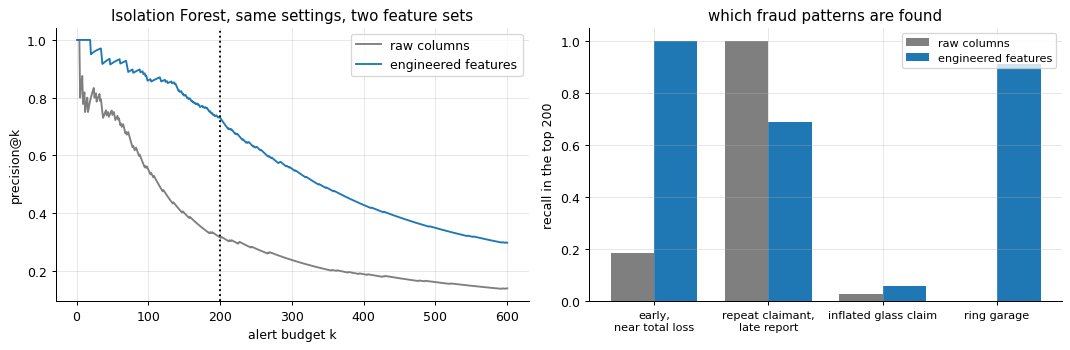

In [26]:
RAW = ["claim_amount", "vehicle_value", "policy_age_days", "policyholder_age", "n_claims_12m", "report_delay_days", "shop_id"]

def engineer(df):
    F = pd.DataFrame(index=df.index)
    F["amount_to_value"] = df.claim_amount / df.vehicle_value
    F["amount_vs_type"] = np.log((df.claim_amount + 10) / df.groupby("claim_type").claim_amount.transform("median"))
    F["log_policy_age"] = np.log1p(df.policy_age_days)
    F["n_claims_12m"] = df.n_claims_12m
    F["log_delay"] = np.log1p(df.report_delay_days)
    F["shop_young_share"] = (df.policy_age_days < 120).groupby(df.shop_id).transform("mean")
    return F

F_cl = engineer(claims); ENG = list(F_cl.columns)
X_raw, X_eng = claims[RAW].to_numpy(float), F_cl.to_numpy(float)
iso_raw = IsolationForest(n_estimators=300, random_state=0).fit(X_raw); s_raw = -iso_raw.score_samples(X_raw)
iso_eng = IsolationForest(n_estimators=300, random_state=0).fit(X_eng); s_eng = -iso_eng.score_samples(X_eng)
BUDGET = 200
rows = []
for name, s in [("raw columns", s_raw), ("engineered features", s_eng)]:
    top = np.argsort(-s)[:BUDGET]
    rec = {p: np.mean(np.isin(np.flatnonzero(claims.pattern == p), top)) for p in PATTERNS}
    rows.append({"features": name, "ROC-AUC": roc_auc_score(y_cl, s), "AP": average_precision_score(y_cl, s),
                 "P@100": precision_at_k(y_cl, s, 100), f"P@{BUDGET}": precision_at_k(y_cl, s, BUDGET), **{f"recall@{BUDGET}: {p}": v for p, v in rec.items()}})
res_cl = pd.DataFrame(rows).set_index("features")
print(res_cl.T.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ks = np.arange(1, 601)
for name, s, c in [("raw columns", s_raw, "tab:gray"), ("engineered features", s_eng, "tab:blue")]:
    axes[0].plot(ks, np.cumsum(y_cl[np.argsort(-s)])[:600] / ks, color=c, label=name)
axes[0].axvline(BUDGET, color="k", ls=":"); axes[0].set_xlabel("alert budget k"); axes[0].set_ylabel("precision@k"); axes[0].legend()
axes[0].set_title("Isolation Forest, same settings, two feature sets")
w = 0.38
for j, (name, c) in enumerate([("raw columns", "tab:gray"), ("engineered features", "tab:blue")]):
    axes[1].bar(np.arange(4) + (j - 0.5) * w, [res_cl.loc[name, f"recall@{BUDGET}: {p}"] for p in PATTERNS], w, color=c, label=name)
axes[1].set_xticks(np.arange(4), [p.replace(", ", ",\n") for p in PATTERNS], fontsize=9); axes[1].set_ylabel(f"recall in the top {BUDGET}")
axes[1].set_title("which fraud patterns are found"); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

**What just happened?** The same Isolation Forest goes from AP 0.280 to 0.758 and from P@200 = 0.315 to 0.730 just by changing what it sees. On the raw columns it finds the repeat claimants (extreme counts and delays are visible as they are) and little else: "€12,000 on a €14,000 car" is two ordinary numbers until you divide them, and the ring garages hide behind an arbitrary `shop_id`. **Feature engineering usually matters more than the choice of algorithm.** (The repeat claimants fall from 100 % to 69 % recall in the top 200 only because the other patterns now compete for the same 200 places.)

One pattern is still missed: the **inflated glass claims** (recall 0.057: 2 of 35). They are extreme on a single feature, `amount_vs_type`, and ordinary on the other five. Each random cut picks that feature only one time in six, and the claim amount of a glass fraud is in the range of normal collisions, so isolation is slow. Detectors that average over many features **dilute single-feature anomalies**; a simple per-feature rule (robust z of `amount_vs_type`) or labels (below) are needed.

**Explaining an alert.** An investigator needs to know *why* a claim was flagged. A simple, model-agnostic explanation: replace one feature at a time by its median and see how much the score drops (an **occlusion** explanation; SHAP values are the principled version of the same idea).

      claim_type  claim_amount  vehicle_value  policy_age_days  n_claims_12m  report_delay_days  shop_id                       pattern  score
2810       theft        8020.0         9500.0             1004             5               49.0      187  repeat claimant, late report  0.745
15515      theft       13570.0        13700.0               21             0                5.0      202                   ring garage  0.741
11518  collision        1800.0        10000.0               28             2                0.0      101                   ring garage  0.740
2850       glass       13320.0        14300.0                4             1                2.0      128        early, near total loss  0.735
15495      theft       12830.0        16400.0               95             6               48.0      171  repeat claimant, late report  0.734
17941  collision        1660.0        14700.0               34             2                0.0      101                   ring garage  0.732
10050 

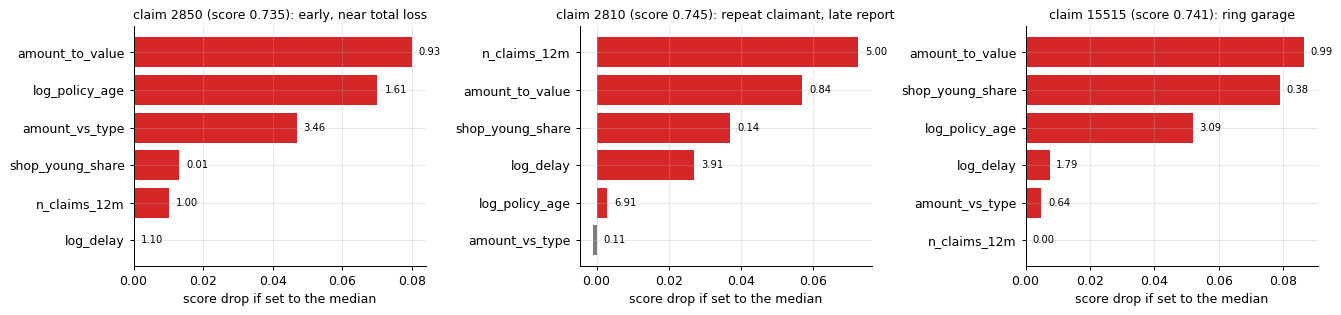

In [27]:
med_eng = np.median(X_eng, axis=0)

def explain(iso, x, med):
    # drop of the anomaly score when feature j is replaced by its median
    base = -iso.score_samples(x[None])[0]
    Xm = np.repeat(x[None], len(med), axis=0); Xm[np.arange(len(med)), np.arange(len(med))] = med
    return base - (-iso.score_samples(Xm))

top10 = np.argsort(-s_eng)[:10]
show_cols = ["claim_type", "claim_amount", "vehicle_value", "policy_age_days", "n_claims_12m", "report_delay_days", "shop_id", "pattern"]
print(claims.loc[top10, show_cols].assign(score=s_eng[top10]).to_string())
picks = [top10[np.flatnonzero(claims.pattern.to_numpy()[top10] == p)[0]] for p in PATTERNS if (claims.pattern.to_numpy()[top10] == p).any()][:3]
fig, axes = plt.subplots(1, len(picks), figsize=(15, 3.6))
for ax, i in zip(axes, picks):
    contrib = explain(iso_eng, X_eng[i], med_eng)
    o = np.argsort(contrib)
    ax.barh(np.array(ENG)[o], contrib[o], color=np.where(contrib[o] > 0, "tab:red", "tab:gray"))
    for j, f in enumerate(o):
        ax.text(max(contrib[f], 0) + 0.002, j, f"{X_eng[i, f]:.2f}", va="center", fontsize=8)
    ax.set_title(f"claim {i} (score {s_eng[i]:.3f}): {claims.pattern[i]}", fontsize=10); ax.set_xlabel("score drop if set to the median")
plt.tight_layout(); plt.show()

**Choosing the threshold from costs.** Say an investigation costs €150 and a fraud that is caught saves its claim amount. Investigating the top $k$ alerts has a net value

$$
V(k) = \sum_{i \le k} y_{(i)}\,\text{amount}_{(i)} - 150\,k ,
$$

and the best budget maximises it. Equivalently, keep investigating while the alerts at the margin are worth it: $P(\text{fraud} \mid \text{this score}) \times \overline{\text{amount}} > 150$, a break-even precision of $150/\overline{\text{amount}}$.

**The `contamination` parameter** of scikit-learn's detectors does not change the scores at all. It only sets the threshold used by `predict` so that the given fraction of the **training** data is flagged. Check it:

mean fraud amount 5,661 EUR -> break-even precision 2.6%
best budget k* = 835: precision 22.4%, frauds caught 187 of 200, net value 937,490 EUR  (k = 100: 670,630;  k = 1000: 928,460)


contamination='auto': predict flags 10.74% of the claims (threshold s > 0.5);  contamination=0.01: flags 1.00%;  scores identical: True


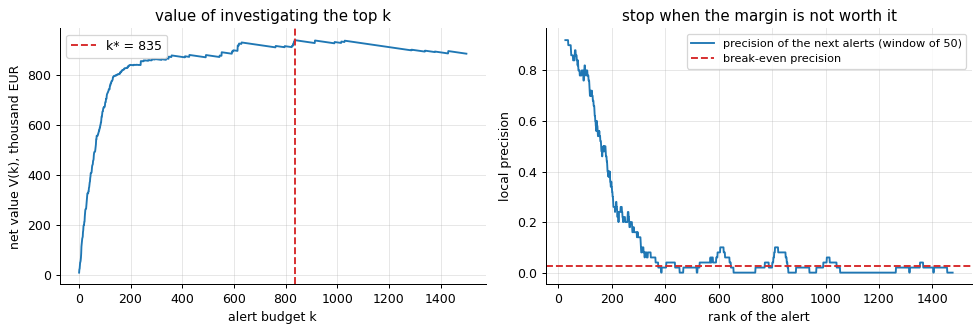

In [28]:
C_INV = 150
order = np.argsort(-s_eng)
amount = claims.claim_amount.to_numpy()
V = np.cumsum((y_cl * amount)[order]) - C_INV * np.arange(1, len(order) + 1)
k_best = int(np.argmax(V)) + 1
mean_fraud_amount = amount[y_cl == 1].mean()
print(f"mean fraud amount {mean_fraud_amount:,.0f} EUR -> break-even precision {C_INV / mean_fraud_amount:.1%}")
print(f"best budget k* = {k_best}: precision {y_cl[order[:k_best]].mean():.1%}, frauds caught {y_cl[order[:k_best]].sum()} of {y_cl.sum()}, "
      f"net value {V[k_best - 1]:,.0f} EUR  (k = 100: {V[99]:,.0f};  k = 1000: {V[999]:,.0f})")

iso_c = IsolationForest(n_estimators=300, contamination=0.01, random_state=0).fit(X_eng)
assert np.allclose(iso_c.score_samples(X_eng), iso_eng.score_samples(X_eng))          # identical scores
print(f"contamination='auto': predict flags {np.mean(iso_eng.predict(X_eng) == -1):.2%} of the claims (threshold s > 0.5);  "
      f"contamination=0.01: flags {np.mean(iso_c.predict(X_eng) == -1):.2%};  scores identical: True")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(np.arange(1, 1501), V[:1500] / 1000); axes[0].axvline(k_best, color="tab:red", ls="--", label=f"k* = {k_best}")
axes[0].set_xlabel("alert budget k"); axes[0].set_ylabel("net value V(k), thousand EUR"); axes[0].legend(); axes[0].set_title("value of investigating the top k")
roll = pd.Series(y_cl[order][:1500]).rolling(50, center=True).mean()
axes[1].plot(np.arange(1, 1501), roll, label="precision of the next alerts (window of 50)")
axes[1].axhline(C_INV / mean_fraud_amount, color="tab:red", ls="--", label="break-even precision")
axes[1].set_xlabel("rank of the alert"); axes[1].set_ylabel("local precision"); axes[1].legend(fontsize=9); axes[1].set_title("stop when the margin is not worth it")
plt.tight_layout(); plt.show()

**From unsupervised scores to a supervised model.** Every investigated alert produces a label. Once enough labels exist, a supervised classifier (the course's gradient boosting) learns the patterns directly, including the ones the unsupervised detector cannot see. Split the claims in time: the first 10,000 are the past, the last 10,000 the future. Compare, on the future claims:

1. the Isolation Forest (unsupervised), fitted on the past;
2. a gradient-boosting classifier trained only on the **500 past claims that were investigated** (the top 500 alerts of the Isolation Forest, labelled by the investigators);
3. the same classifier trained on **all** past labels (for example after an audit);
4. the classifier of 3 with the Isolation Forest score as an extra feature.

investigated alerts: 500, of which 104 frauds (of 106 in the past)
                                            AP  P@100 glass frauds in the top 100
model                                                                            
Isolation Forest (no labels)             0.716   0.64                      1 / 21
boosting on the 500 investigated alerts  0.784   0.77                     16 / 21
boosting on all past labels              0.981   0.88                     15 / 21
boosting on all past labels + IF score   0.966   0.85                     12 / 21


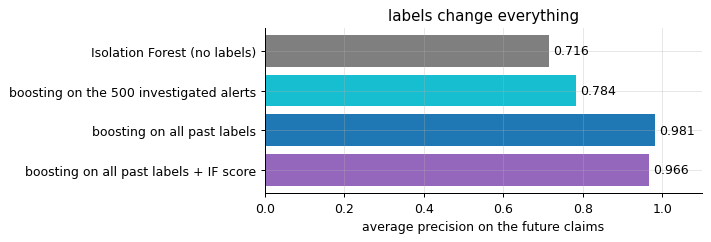

In [29]:
past = claims.claim_id.to_numpy() < 10_000; fut = ~past
iso_p = IsolationForest(n_estimators=300, random_state=0).fit(X_eng[past])
s_if_past, s_if_fut = -iso_p.score_samples(X_eng[past]), -iso_p.score_samples(X_eng[fut])
inv = np.argsort(-s_if_past)[:500]                                   # what the investigators reviewed
models = {
    "Isolation Forest (no labels)": s_if_fut,
    "boosting on the 500 investigated alerts": HistGradientBoostingClassifier(random_state=0).fit(X_eng[past][inv], y_cl[past][inv]).predict_proba(X_eng[fut])[:, 1],
    "boosting on all past labels": HistGradientBoostingClassifier(random_state=0).fit(X_eng[past], y_cl[past]).predict_proba(X_eng[fut])[:, 1],
    "boosting on all past labels + IF score": HistGradientBoostingClassifier(random_state=0).fit(
        np.c_[X_eng[past], s_if_past], y_cl[past]).predict_proba(np.c_[X_eng[fut], s_if_fut])[:, 1],
}
print(f"investigated alerts: {len(inv)}, of which {y_cl[past][inv].sum()} frauds (of {y_cl[past].sum()} in the past)")
rows = []
for name, s in models.items():
    top = np.argsort(-s)[:100]; pat = claims.pattern.to_numpy()[fut]
    rows.append({"model": name, "AP": average_precision_score(y_cl[fut], s), "P@100": y_cl[fut][top].mean(),
                 "glass frauds in the top 100": f"{np.sum(pat[top] == 'inflated glass claim')} / {np.sum(pat == 'inflated glass claim')}"})
res_sup = pd.DataFrame(rows).set_index("model")
print(res_sup.round(3).to_string())
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.barh(res_sup.index[::-1], res_sup.AP[::-1], color=["tab:purple", "tab:blue", "tab:cyan", "tab:gray"])
for j, v in enumerate(res_sup.AP[::-1]):
    ax.text(v + 0.01, j, f"{v:.3f}", va="center")
ax.set_xlim(0, 1.1); ax.set_xlabel("average precision on the future claims"); ax.set_title("labels change everything")
plt.tight_layout(); plt.show()

**Interpretation.**
- The cost curve peaks at $k^* =$ 835 alerts (precision 22.4 %, net value 937,490 EUR). The break-even precision is only 2.6 % because a fraud is worth about 5,661 EUR: beyond the top few hundred alerts each investigation still pays, until the local precision drops below it.
- `contamination` changed nothing in the scores; it moved the cut of `predict` from 10.7 % of the claims (the paper's rule $s > 0.5$) to exactly 1 %. Tune the threshold on costs and budgets, not by guessing the contamination.
- With labels, the problem becomes supervised and much easier: AP 0.981 with all past labels, against 0.716 for the unsupervised forest. Even the biased sample of 500 investigated alerts (104 frauds) gives AP 0.784. The classifier learns the inflated glass claims that the forest missed (15 of the 21 future glass frauds in its top 100 against 1). Adding the Isolation Forest score as a feature gives AP 0.966, no better: with all the labels, the score adds nothing the features do not already say.
- The practical loop: start unsupervised, investigate the top alerts, feed the labels back, move to a supervised model, and keep an unsupervised detector running for the **new** patterns that no label describes yet. Beware of the bias: a model trained only on investigated alerts learns what the old detector already found.

## 12. Time series: seasonality and contextual baselines

Daily number of claims reported to the same fictional insurer over three years. Normal behaviour has a **yearly season** (storms and ice in winter: about twice as many claims as in summer), a **weekly pattern** (quiet weekends, busy Mondays), a slow upward **trend**, and Poisson noise. We inject four anomalies, 8 days in total: a spike in mid-summer, a dip (a reporting outage), a 5-day hailstorm, and a spike in early December.

Three detectors:
1. **global threshold**: mean ± 3 standard deviations of the whole series;
2. **rolling seasonal baseline**: the median of the same weekday over the previous 4 weeks (only the past: no look-ahead), and for counts the Poisson scale $\sqrt{\text{baseline}}$: $z_t = (y_t - b_t)/\sqrt{b_t}$;
3. **calendar model**: a Poisson regression on weekday, yearly Fourier terms ($\sin$, $\cos$ of $2\pi j\,\text{day}/365.25$, $j = 1, 2$) and a trend, fitted on the first year only, then $z_t = (y_t - \hat\mu_t)/\sqrt{\hat\mu_t}$. This is the regression of the course's time-series lab, used as a baseline.

In [30]:
def make_daily_claims(seed=3):
    rng = np.random.default_rng(seed)
    days = pd.date_range("2023-01-01", periods=3 * 365, freq="D")
    t = np.arange(len(days)); doy, dow = days.dayofyear.to_numpy(), days.dayofweek.to_numpy()
    season = 1 + 0.35 * np.cos(2 * np.pi * (doy - 15) / 365.25)             # winter peak
    week = np.where(dow >= 5, 0.6, 1.0) * np.where(dow == 0, 1.15, 1.0)     # quiet weekends, busy Mondays
    mu = 80 * season * week * (1 + 0.10 * t / len(t))
    y = rng.poisson(mu).astype(float); truth = np.zeros(len(t), bool)
    events = [("summer spike", "2024-07-17", 1, "+45"), ("hailstorm", "2024-05-20", 5, "x1.6"),
              ("outage (dip)", "2025-02-12", 1, "x0.3"), ("December spike", "2025-12-03", 1, "+60")]
    for name, start, L, eff in events:
        i0 = days.get_loc(pd.Timestamp(start))
        for i in range(i0, i0 + L):
            y[i] = y[i] + float(eff[1:]) if eff[0] == "+" else round(mu[i] * float(eff[1:]))
            truth[i] = True
    return days, y, mu, truth, events

days, y_ts, mu_ts, truth_ts, events = make_daily_claims()
first_year = days.year == 2023

# 1. global threshold
m_, sd_ = y_ts.mean(), y_ts.std()
flag_glob = (y_ts > m_ + 3 * sd_) | (y_ts < m_ - 3 * sd_)
# 2. rolling seasonal baseline: same weekday, previous 4 weeks
lags = np.column_stack([np.r_[np.full(7 * j, np.nan), y_ts[:-7 * j]] for j in range(1, 5)])
base_roll = np.median(lags, axis=1)                         # NaN for the first 4 weeks
z_roll = (y_ts - base_roll) / np.sqrt(base_roll)
# 3. calendar model fitted on the first year
def calendar_features(days):
    doy, dow, t = days.dayofyear.to_numpy(), days.dayofweek.to_numpy(), np.arange(len(days)) / 365.25
    cols = [np.eye(7)[dow][:, 1:], t[:, None]]
    for j in (1, 2):
        cols += [np.sin(2 * np.pi * j * doy / 365.25)[:, None], np.cos(2 * np.pi * j * doy / 365.25)[:, None]]
    return np.hstack(cols)
Xcal = calendar_features(days)
pois = PoissonRegressor(alpha=1e-6, max_iter=1000).fit(Xcal[first_year], y_ts[first_year])
mu_hat = pois.predict(Xcal)
z_cal = (y_ts - mu_hat) / np.sqrt(mu_hat)

THR = 4.0
evaluate = ~first_year                                       # 2024-2025: the period every method can score
flags = {"global mean ± 3 sd": flag_glob, f"rolling baseline, |z| > {THR:.0f}": np.abs(np.nan_to_num(z_roll)) > THR,
         f"calendar model, |z| > {THR:.0f}": np.abs(z_cal) > THR}
for name, f in flags.items():
    f = f & evaluate
    n_fa = np.sum(f & ~truth_ts)
    print(f"{name:28s}: {np.sum(f & truth_ts)} of {truth_ts.sum()} anomalous days found, {n_fa} false alarm{'' if n_fa == 1 else 's'}"
          + (f" ({', '.join(str(d.date()) for d in days[f & ~truth_ts])})" if 0 < n_fa < 4 else ""))
print(f"global threshold band: [{m_ - 3 * sd_:.0f}, {m_ + 3 * sd_:.0f}];  normal days above the summer spike's {y_ts[days.get_loc(pd.Timestamp('2024-07-17'))]:.0f} claims:"
      f" {np.sum((y_ts >= y_ts[days.get_loc(pd.Timestamp('2024-07-17'))]) & ~truth_ts)}")
print(f"std of the calendar-model z on normal days of 2024-2025: {z_cal[evaluate & ~truth_ts].std():.2f} (1 for a perfect Poisson model)")

global mean ± 3 sd          : 0 of 8 anomalous days found, 0 false alarms
rolling baseline, |z| > 4   : 5 of 8 anomalous days found, 1 false alarm (2024-06-12)
calendar model, |z| > 4     : 7 of 8 anomalous days found, 0 false alarms
global threshold band: [-5, 157];  normal days above the summer spike's 98 claims: 269
std of the calendar-model z on normal days of 2024-2025: 1.08 (1 for a perfect Poisson model)


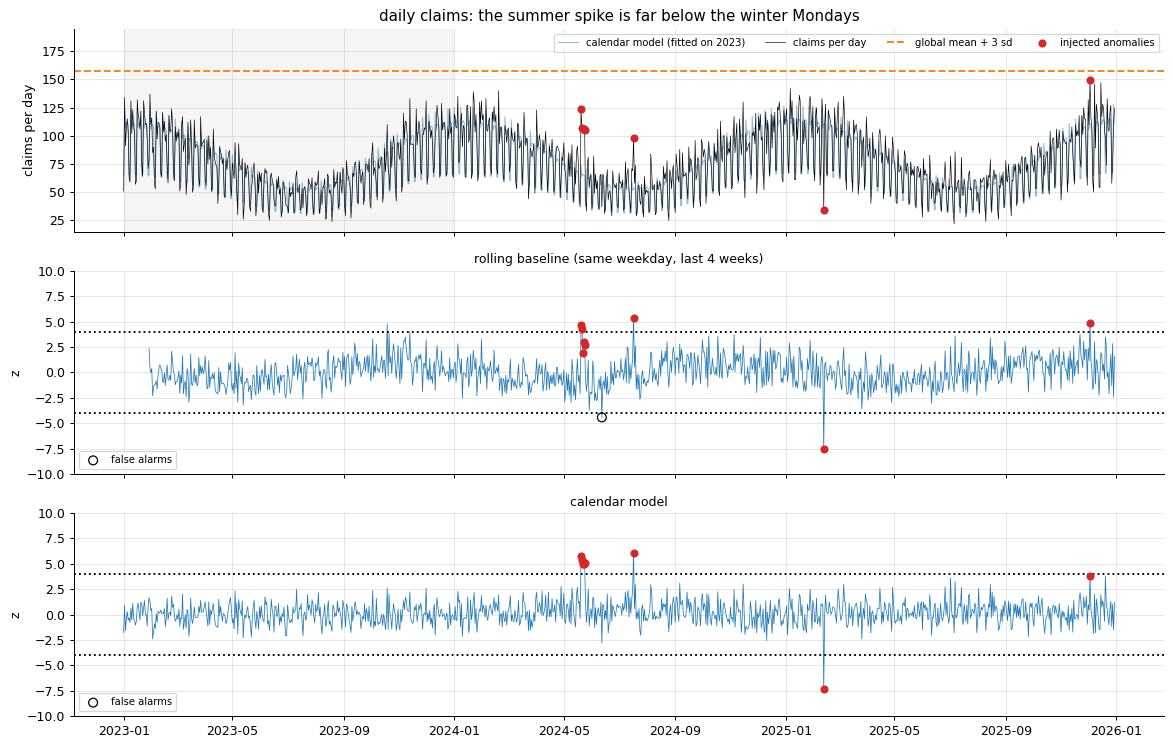

summer spike    2024-07-17: y = 98, rolling baseline 58 (z +5.3), calendar model 53 (z +6.1)
hailstorm       2024-05-20: y = 124, rolling baseline 82 (z +4.7), calendar model 74 (z +5.8)
outage (dip)    2025-02-12: y = 34, rolling baseline 116 (z -7.6), calendar model 110 (z -7.3)
December spike  2025-12-03: y = 149, rolling baseline 100 (z +4.9), calendar model 110 (z +3.8)


In [31]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8.4), sharex=True)
ax = axes[0]
ax.plot(days, mu_hat, color="tab:blue", lw=0.8, alpha=0.5, label="calendar model (fitted on 2023)"); ax.plot(days, y_ts, color="k", lw=0.5, label="claims per day")
ax.axhline(m_ + 3 * sd_, color="tab:orange", ls="--", label="global mean + 3 sd")
ax.scatter(days[truth_ts], y_ts[truth_ts], c="tab:red", s=30, zorder=3, label="injected anomalies")
ax.set_ylabel("claims per day"); ax.set_ylim(15, 195); ax.legend(loc="upper right", fontsize=8, ncol=4); ax.set_title("daily claims: the summer spike is far below the winter Mondays")
for ax, z, name in [(axes[1], z_roll, "rolling baseline (same weekday, last 4 weeks)"), (axes[2], z_cal, "calendar model")]:
    ax.plot(days, z, color="tab:blue", lw=0.6); ax.axhline(THR, color="k", ls=":"); ax.axhline(-THR, color="k", ls=":")
    ax.scatter(days[truth_ts], z[truth_ts], c="tab:red", s=30, zorder=3)
    fp = (np.abs(np.nan_to_num(z)) > THR) & ~truth_ts & evaluate
    ax.scatter(days[fp], z[fp], facecolors="none", edgecolors="k", s=50, zorder=3, label="false alarms")
    ax.set_ylabel("z"); ax.set_ylim(-10, 10); ax.set_title(name, fontsize=10); ax.legend(loc="lower left", fontsize=8)
axes[0].axvspan(days[0], days[364], color="gray", alpha=0.08)
plt.tight_layout(); plt.show()
for name, start, L, eff in events:
    i = days.get_loc(pd.Timestamp(start))
    print(f"{name:15s} {start}: y = {y_ts[i]:.0f}, rolling baseline {base_roll[i]:.0f} (z {z_roll[i]:+.1f}), calendar model {mu_hat[i]:.0f} (z {z_cal[i]:+.1f})")

**What just happened?**
- The **global threshold** finds none of the 8 anomalous days. The summer spike (98 claims) is unremarkable for the whole series: 269 normal days, mostly winter weekdays, have more claims. A global rule has to choose between missing it and drowning in winter alarms. This is the **contextual anomaly** of section 1: unusual for a Wednesday in July, normal for a Monday in January.
- The **rolling baseline** compares each day with the same weekday in the previous weeks: 5 of 8 found and one false alarm (12 June 2024, three weeks after the hailstorm, whose Wednesday is still one of its four reference days). It adapts to the season but **lags behind it**: in spring the claims fall quickly, the 4-week median is still high, and the hailstorm (z = +4.7, against +5.8 for the calendar model on its first day) looks smaller than it is.
- The **calendar model** knows the season of the date, so it has no lag: 7 of 8 found and no false alarm; it misses only the December spike ($z = +3.8$, just under the threshold of 4). Its z-scores on normal days have a standard deviation of 1.08, close to the 1 of a perfect Poisson model.
- Rules for time series: only the **past** may enter the baseline (a centred window would let the hailstorm raise its own baseline, and does not exist in production); refit the baseline as the business **drifts** (new products, a new claims portal); and a run of moderate days (the hailstorm) is a **collective** anomaly that a sum of the last few $z$ (CUSUM) detects better than any single day.

In [32]:
print(f"whole notebook: {(time.time() - T_START) / 60:.1f} min on {device}")

whole notebook: 0.5 min on cpu


## 13. Summary

- **Setting**: supervised (labelled anomalies: imbalanced classification), novelty detection (clean normal data), outlier detection (contaminated, unlabelled). Every detector gives a score $s(\mathbf{x})$; a decision needs a threshold or an alert budget.
- **Base rates**: precision $= \text{TPR}\,\pi/(\text{TPR}\,\pi + \text{FPR}(1-\pi))$. TPR 90 %, FPR 1 %, $\pi$ = 0.1 %: precision 8.3 %. Report precision@$k$ and AP, not accuracy.
- **One feature**: $|z| \le \sqrt{n-1}$ always, and outliers mask each other ($z \to \sqrt{(n-m)/m}$). Use the robust $z_r = 0.6745\,(x - \operatorname{med})/\operatorname{MAD}$ or Tukey's fences. Ten claims: $z$ = 2.10, $z_r$ = 24.3.
- **Several features**: $D_M^2 = (\mathbf{x}-\boldsymbol\mu)^\top\boldsymbol\Sigma^{-1}(\mathbf{x}-\boldsymbol\mu) \sim \chi^2_d$ for Gaussian data (threshold 7.38 for $d = 2$). With 13 % contamination the classical estimate flagged 2 of 45 outliers, the MCD 45.
- **Distance and density**: the $k$-NN distance and the KDE are global scores (a GMM adapts its scale per component, if the clusters really are Gaussian). **LOF** $= \operatorname{mean}_{\mathbf{o}\in N_k}\operatorname{lrd}(\mathbf{o})/\operatorname{lrd}(\mathbf{x})$ is local: 1 inside any cluster (worked example: 1.00, 1.35, 3.02).
- **Isolation Forest**: $s = 2^{-\mathbb{E}[h]/c(\psi)}$, $c(n) = 2H(n-1) - 2(n-1)/n$, $c(256) = 10.24$; sub-samples of 256 points, cost independent of $n$. A good default for tabular data.
- **One-class SVM**: fraction of outliers $\le \nu \le$ fraction of support vectors; $\gamma$ matters as much as $\nu$.
- **Satellite** ($\pi$ = 1.5 %): ROC-AUC from 0.68 to 0.97, AP from 0.15 to 0.64. GMM: ROC-AUC 0.939 but precision 12.4 % at 80 % recall. Ensemble of 3 (mean of z-scores): AP 0.653.
- **Reconstruction** (normal = eights): PCA AUC 0.861, autoencoder 0.897; ones are missed (AUC 0.463) because simple inputs reconstruct well; dividing by the ink gives 0.955. Likelihoods of deep generative models have the same flaw.
- **Claims**: engineered features took the Isolation Forest from AP 0.280 to 0.758; with labels, gradient boosting reaches 0.981. Explain alerts by occlusion; choose $k$ from costs; `contamination` only moves `predict`'s cut.
- **Time series**: global threshold none of 8, rolling baseline 5 of 8, calendar model 7 of 8. Baselines must be contextual and use only the past.

## Exercises

Try each one before opening the answer.

1. **The 3-sigma rule with few data.** With $n = 9$ values and $\sigma$ computed with $1/n$, what is the largest possible $|z|$? And with the sample standard deviation ($1/(n-1)$)? What does that mean for a "$|z| > 3$" rule on a small group of claims?
2. **Mahalanobis by hand.** With $\boldsymbol\mu = \mathbf{0}$ and $\boldsymbol\Sigma = \begin{pmatrix}1 & 0.8\\ 0.8 & 1\end{pmatrix}$, compute $D_M$ for $(1, 1)$ and $(1, -1)$. Which one is flagged at the 97.5 % level?
3. **LOF by hand.** In the six-point example add a seventh point G = (8, 7) next to F. With $k = 1$, what are $\operatorname{LOF}(F)$ and $\operatorname{LOF}(G)$? And with $k = 2$? What does this say about choosing $k$?
4. **Isolation Forest numbers.** Compute $c(2)$, $c(8)$ and $c(256)$. A point has $\mathbb{E}[h] = 4$ with $\psi = 256$: what is its score? Which $\mathbb{E}[h]$ gives exactly $s = 0.5$, and why does that make sense?
5. **The $\nu$-property.** A one-class SVM with $\nu = 0.05$ is trained on 2,000 points. At most how many training points are strictly outside the boundary, and at least how many are support vectors? Why?
6. **Base rates and budgets.** A detector has TPR 95 % and FPR 0.5 %. The insurer receives 10,000 claims a day, with a fraud rate of 0.2 %, and the team can investigate 40 claims a day. What is the precision of the alerts? Can the team review them all? If not, what should it do?
7. **Leakage in time.** Why must the rolling baseline of section 12 use only past days? What would a centred window (the 2 weeks before and after) do to the 5-day hailstorm?

<details>
<summary><b>Answers</b></summary>

**1.** With $1/n$: $|z| \le \sqrt{n-1} = \sqrt8 = 2.83$. With $1/(n-1)$, $s^2 = \frac{n}{n-1}\sigma^2$, so the bound becomes $\sqrt{n-1}\,\sqrt{(n-1)/n} = (n-1)/\sqrt n = 8/3 = 2.67$. Either way a "$|z| > 3$" rule **can never fire** on 9 values, however absurd one of them is; even with more data a few large values mask each other. Use the robust z (median, MAD) or Tukey's fences for small groups.

**2.** $\boldsymbol\Sigma^{-1} = \frac{1}{1 - 0.64}\begin{pmatrix}1 & -0.8\\ -0.8 & 1\end{pmatrix} = 2.778\begin{pmatrix}1 & -0.8\\ -0.8 & 1\end{pmatrix}$. For $(1, 1)$: $D^2 = 2.778\,(1 - 1.6 + 1) = 1.111$, $D = 1.05$. For $(1, -1)$: $D^2 = 2.778\,(1 + 1.6 + 1) = 10.0$, $D = 3.16$. Both are at Euclidean distance $\sqrt2$ from the centre, but only $(1, -1)$, which goes against the correlation, exceeds $\chi^2_{2,\,0.975} = 7.38$.

**3.** With $k = 1$, F's nearest neighbour is G and G's is F (distance 1), so $d_1(F) = d_1(G) = 1$, $\operatorname{reach}(F, G) = \max(1, 1) = 1$, $\operatorname{lrd}(F) = \operatorname{lrd}(G) = 1$ and $\operatorname{LOF}(F) = \operatorname{LOF}(G) = 1$: the pair hides itself completely. With $k = 2$, F's neighbours are G (1) and E ($\sqrt{34} = 5.83$); G's are F (1) and E ($\sqrt{41} = 6.40$). $d_2(F) = 5.83$, $d_2(G) = 6.40$, $d_2(E) = \sqrt{10} = 3.16$. $\operatorname{lrd}(F) = 1/\operatorname{mean}(\max(1, 6.40), \max(5.83, 3.16)) = 1/6.12 = 0.163$, $\operatorname{lrd}(G) = 1/\operatorname{mean}(\max(1, 5.83), \max(6.40, 3.16)) = 1/6.12 = 0.163$, and $\operatorname{lrd}(E) = 0.370$ (unchanged, E's neighbours are still D and B). $\operatorname{LOF}(F) = \operatorname{mean}(0.163, 0.370)/0.163 = 1.63$, and the same for G. So a group of $m$ outliers is invisible for $k \le m - 1$ and only partly visible just above: choose $k$ larger than the largest anomalous group you want to catch.

**4.** $c(2) = 1$; $c(8) = 2(\ln 7 + 0.5772) - 2 \cdot 7/8 = 2(1.946 + 0.577) - 1.75 = 3.30$; $c(256) = 2(\ln 255 + 0.5772) - 2 \cdot 255/256 = 10.24$. With $\mathbb{E}[h] = 4$: $s = 2^{-4/10.24} = 0.763$. $s = 0.5$ when $\mathbb{E}[h] = c(\psi)$: the point needs exactly as many cuts as an average point of a random tree, so nothing distinguishes it. Values well above 0.5 (shorter paths) are suspicious; values well below are typical of dense regions.

**5.** In the dual, outliers have $\alpha_i = 1/(\nu n)$ and $\sum_i \alpha_i = 1$, so there are at most $\nu n = 100$ of them. Support vectors have $0 < \alpha_i \le 1/(\nu n)$, so at least $\nu n = 100$ are needed to reach a total of 1. So at most 100 points (5 %) outside and at least 100 support vectors.

**6.** Frauds per day: 20; true alerts $0.95 \times 20 = 19$; false alarms $0.005 \times 9{,}980 = 49.9$. About 69 alerts a day, precision $19/68.9 = 27.6\,\%$. The team can review only 40, so it must rank: investigate the 40 highest scores (precision@40 is what matters), and use the cost curve of section 11 to argue for a larger team if the alerts at the margin are still worth more than an investigation. Lowering the false positive rate (better features, section 11) helps more than raising the recall.

**7.** In production, on the day we score, the future does not exist yet, so a baseline that uses future days cannot be computed; any evaluation that uses one is optimistic (look-ahead leakage). Moreover a centred window would contain the hailstorm itself: its 5 high days would raise the median of the surrounding weeks, raising the baseline exactly when we want to detect them, and the rolling MAD or variance would also grow. The anomaly would partly explain itself away.

</details>